In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserImputeFunctions as ui

# set seaborn theme
sns.set_theme()

# initializing variables
REMOVE = '** REMOVE ** Engineer'
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# initialize DataFrame
df_new = pd.DataFrame(columns=['column'])

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


### Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/3Clean_Heart.pkl")
df_label = pd.read_pickle("../Data/3Clean_Label.pkl")
df_can = pd.read_pickle("../Data/3Clean_CAN.pkl")
df_don = pd.read_pickle("../Data/3Clean_DON.pkl")
df_both = pd.read_pickle("../Data/3Clean_Both.pkl")
df_nominal = pd.read_pickle("../Data/3Clean_Nominal.pkl")
df_ordinal = pd.read_pickle("../Data/3Clean_Ordinal.pkl")
df_numeric = pd.read_pickle("../Data/3Clean_Numeric.pkl")
df_object = pd.read_pickle("../Data/3Clean_Object.pkl")
df_date = pd.read_pickle("../Data/3Clean_Date.pkl")
df_dict = pd.read_pickle("../Data/3Clean_Dictionary.pkl")
df_drop = pd.read_pickle("../Data/3Clean_Drop.pkl")
df_unknown = pd.read_pickle("../Data/3Clean_Unknown.pkl")

# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

### Feature Information

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Drop Features: {df_drop.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"Dictionary Features: {df_dict.shape[0]:,}")

Heart Dataset Rows: 27,494 & Columns: 261
Label Features: 15
Candidate Features: 139
Donor Features: 95
Date Features: 14
Both Features: 7
Object Features: 11
Numeric Features: 45
Ordinal Features: 13
Nominal Features: 179
Drop Features: 0
Unknown Features: 0
Dictionary Features: 302


In [4]:
# all label features
labelCols = df_label.column.to_list()

# display
df[labelCols].head()

,AcuteRejectionEpisode,AirwayDehiscencePostTransplant,StrokePostTransplant,PacemakerPostTransplant,DialysisPostDischarge,GraftFailStatus,GraftLifeSpanDay,LastFollowupNumber,GraftStatus,TransplantStatus,TransplantSurvivalDay,RecipientStatus,RejectionTreatmentWithinOneYear,FunctionalStatusFollowUp,LengthOfStay
0,No,No,No,No,Yes,Failure,329.0,999,No,Dead,329.0,Dead,No,"100% - Normal, no complaints, no evidence of disease",76.0
1,No,No,No,No,No,Success,2592.0,80,Yes,Alive,2592.0,Living,Missing,Unknown,10.0
2,No,No,No,No,No,Success,2913.0,80,Yes,Alive,2913.0,Living,No,Unknown,21.0
3,"Yes, at least one episode treated with anti-rejection agent",No,No,No,No,Failure,1225.0,999,No,Dead,1225.0,Dead,Yes,"30% - Severely disabled: hospitalization is indicated, death not imminent",32.0
4,No,No,No,No,No,Success,2785.0,80,Yes,Alive,2785.0,Living,No,Unknown,26.0


### Remove Unwanted Features

In [5]:
# all ordinal columns
removeCols = df_object.column.to_list()

# display
df[removeCols].head()

,VentricularDeviceTypeRegistration_CAN,VentricularDeviceTypeTransplant_CAN,VentricularDeviceBrandRegistration_CAN,VentricularDeviceBrandTransplant_CAN,PrimaryPaymentRegistration_CAN,PrimaryPaymentTransplant_CAN,DialysisTypeRegistration_CAN,CancerSite_DON,OtherMedsText1_DON,OtherMedsText2_DON,OtherMedsText3_DON
0,Lvad+Rvad,Lvad+Rvad,CentriMag (Thoratec/Levitronix),CentriMag (Thoratec/Levitronix),Public insurance - Medicaid,Public insurance - Medicaid,No dialysis,NO,"ZOSYN, VANCOMYCIN","KCL,","DOPAMINE, VASOPRESSIN,"
1,Lvad,Lvad,Heartmate II,Heartmate II,Public insurance - Medicare FFS (Fee for Service),Public insurance - Medicare FFS (Fee for Service),No dialysis,NO,"ANCEF, FENTANYL, VERSED,LASIX",NaN,NaN
2,None,None,Missing,Missing,Private insurance,Private insurance,No dialysis,NO,"ZOSYN, VANCOMYCIN","AMPHOTERICIN, BETADINE",ZANTAC
3,Lvad+Rvad,Lvad,CentriMag (Thoratec/Levitronix),Heartmate II,Public insurance - Medicare & Choice,Private insurance,No dialysis,"SKIN - SQUAMOUS, BASAL CELL","KCL, VANCO, MAG, ZOSYN","D50, DOPAMINE, DIFLUCAN",NaN
4,Lvad,Lvad,Heartmate II,Heartmate II,Public insurance - Medicare & Choice,Public insurance - Medicare & Choice,No dialysis,NO,"ROCURONIUM, VECURONIUM","ZOSYN, CIPROFLOXACIN","BUMETIDE, ANCEF"


In [6]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 6 row(s) from df_can DataFrame.
Remove 4 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 11 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['CancerSite_DON', 'DialysisTypeRegistration_CAN', 'OtherMedsText1_DON', 'OtherMedsText2_DON', 'OtherMedsText3_DON', 'PrimaryPaymentRegistration_CAN', 'PrimaryPaymentTransplant_CAN', 'VentricularDeviceBrandRegistration_CAN', 'VentricularDeviceBrandTransplant_CAN', 'VentricularDeviceTypeRegistration_CAN', 'VentricularDeviceTypeTransplant_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 27,494 & columns: 261
Total Row(s) & Column(s) After Removing Column(s): 27,494 & columns: 250


### ListingYear

In [7]:
uf.categoryContingency(df, 'ListingYear', 'RecipientStatus')

RecipientStatus,Dead,Living,Lost to Follow Up,Missing,Retransplanted,Row Total,Dead %,Living %
ListingYear,,,,,,,,
2011,664.0,1273.0,47.0,0.0,34.0,2018.0,32.903865,63.082260
2012,643.0,1438.0,32.0,0.0,35.0,2148.0,29.934823,66.945996
2013,620.0,1568.0,38.0,0.0,31.0,2257.0,27.470093,69.472751
2014,576.0,1791.0,26.0,0.0,26.0,2419.0,23.811492,74.038859
2015,512.0,1963.0,28.0,0.0,23.0,2526.0,20.269200,77.711797
2016,496.0,2112.0,13.0,0.0,17.0,2638.0,18.802123,80.060652
2017,436.0,2191.0,5.0,0.0,12.0,2644.0,16.490166,82.866868
2018,357.0,2363.0,4.0,3.0,24.0,2751.0,12.977099,85.896038
2019,358.0,2494.0,1.0,12.0,8.0,2873.0,12.460842,86.808214


#### Plot

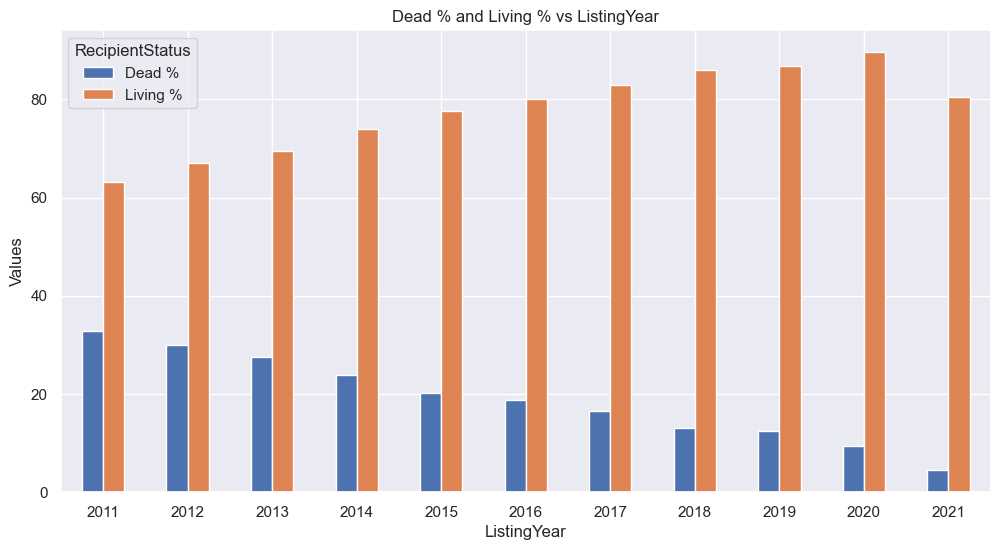

In [8]:
# get table into DataFrame
data = uf.categoryContingency(df, 'ListingYear', 'RecipientStatus')
# exclude the last row
data = data.iloc[:-1]

# 'Dead %' or 'Living %'
data = data[['Dead %', 'Living %']]

# Plotting the bar plot
data.plot(kind='bar', figsize=(12,6))
plt.title('Dead % and Living % vs ListingYear')
plt.xlabel('ListingYear')
plt.ylabel('Values')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

#### Note: 2016, 2017, 2018, 2019, 2020, 2021 ONLY
- Let ONLY take Five years from 2020

In [9]:
df = df[df.ListingYear.isin([2016,2017,2018,2019,2020, 2021])].copy()

df.shape

(16126, 250)

In [10]:
# initialize list
removeCols = df_date.column.to_list()

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 7 row(s) from df_can DataFrame.
Remove 3 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 14 row(s) from df_date DataFrame.

Removed Features: ['AdmissionDate_CAN', 'AdmissionDate_DON', 'AllocationBeginDate_CAN', 'CenterDischargeDate_CAN', 'InitialWaitListDate_CAN', 'ListingYear', 'OrganRecoveryDate_DON', 'ReferralDate_DON', 'RemovalWaitListDate_CAN', 'StatusDate_CAN', 'TransplantDate_CAN', 'ValidationDateTCR_CAN', 'ValidationDateTCR_DDR', 'ValidationDateTRR_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 16,126 & columns: 250
Total Row(s) & Column(s) After Removing Column(s): 16,126 & columns: 236


### Wrangle Data

#### Remove Date & NaNs > 40%

In [11]:
# get NaNs
NaNsDF = uf.percentageNull(df)

# remove NaNs
removeCols = NaNsDF.index[NaNsDF.percentage > 40].to_list()

# append text fields
removeCols.extend(df_date.column.to_list())

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 4 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 1 row(s) from df_nominal DataFrame.
Remove 3 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Class1PRA_TransplantPercentage_CAN', 'Class2PRA_TransplantPercentage_CAN', 'PriorCardiacSurgeryTypeText_CAN', 'TotalSerumAlbuminRegistration_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 16,126 & columns: 236
Total Row(s) & Column(s) After Removing Column(s): 16,126 & columns: 232


#### Numerical Features

In [12]:
print(sorted(df_numeric.column.to_list()))

['Age_CAN', 'Age_DON', 'Age_Listing_CAN', 'BMI_CAN', 'BMI_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CPRA_Peak_CAN', 'CPRA_Recent_CAN', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_DON', 'DistanceFromDonorHospitaltoTXCenter', 'GraftLifeSpanDay', 'HeightCm_CAN', 'HeightCm_DON', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'HemodynamicsTransplant_PA_DIA_CAN', 'HemodynamicsTransplant_PA_MN_CAN', 'HemodynamicsTransplant_PCW_CAN', 'HemodynamicsTransplant_SYS_CAN', 'IschemicTimeHour_DON', 'LV_EjectionFractionPercent_DON', 'LastFollowupNumber', 'LengthOfStay', 'Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON', 'LungPO2_DON', 'LungPO2_FIO2_DON', 'OrganRecovery_PCO2_DON', 'TerminalTotalBilirubin_DON', 'TotalBilirubinTransplant_CAN', 'TotalDayWaitList_CAN', 'TransplantSurvivalDay', 

##### Age
- Remove:
    - Age_Listing_CAN 

In [13]:
# examine features
features = uf.getFeatureList(df, 'Age_')

                   count       mean        std   min   25%   50%    75%   max
Age_CAN          16126.0  53.550229  12.917136  18.0  46.0  57.0  64.00  77.0
Age_DON          16126.0  32.261441  10.644595   8.0  24.0  31.0  39.75  70.0
Age_Listing_CAN  16126.0  53.165447  12.937125  15.0  46.0  56.0  63.00  77.0

:::: NaN Count:
Age_CAN            0
Age_DON            0
Age_Listing_CAN    0


In [14]:
# create new feature
df['Age_Difference'] = df.Age_CAN - df.Age_DON
df['Age_Addition'] = df.Age_CAN + df.Age_DON

# initialize list
new = ['Age_Difference', 'Age_Addition']
removeCols = ['Age_Listing_CAN']

# update dataframe
df_drop  = uf.insertIntoDataFrame(df_drop, features)
df_numeric = uf.insertIntoDataFrame(df_numeric, new)
df_new = uf.insertIntoDataFrame(df_new, new)
df_both = uf.insertIntoDataFrame(df_both, new)

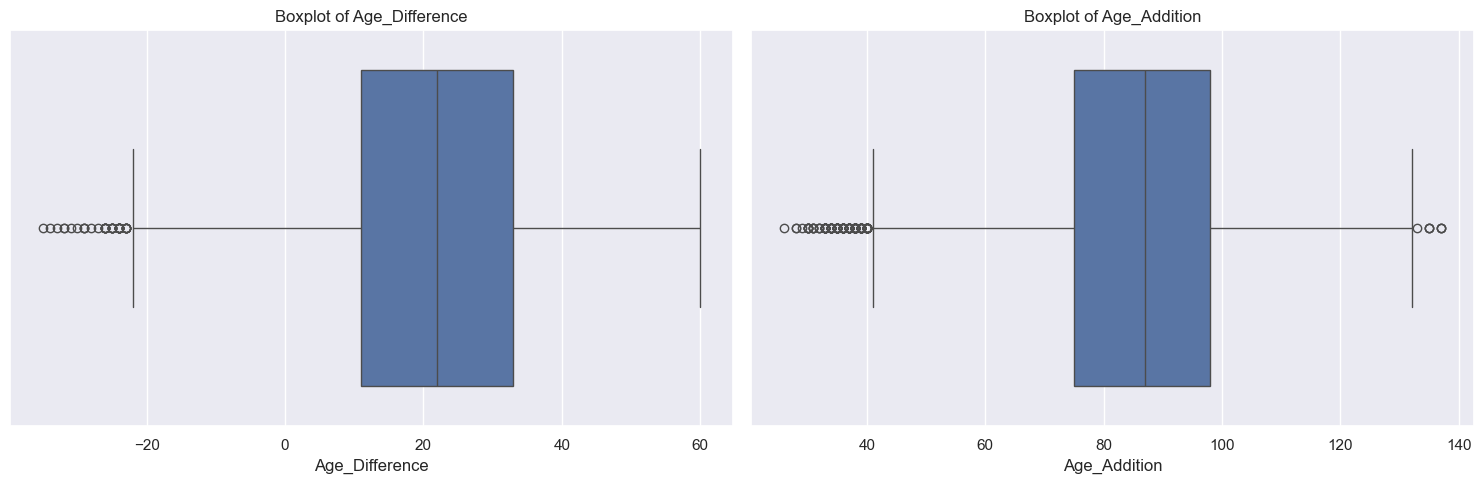

In [15]:
# boxplot
uv.plotBoxPlot(df, new, orientation='h')

##### BMI
##### The standard BMI ranges for adults are:
- Underweight: BMI less than 18.5 kg/m²
- Normal weight: BMI 18.5 to 24.9 kg/m²
- Overweight: BMI 25 to 29.9 kg/m²
- Obesity: BMI 30 kg/m² or greater

In [16]:
# examine features
features = uf.getFeatureList(df, 'BMI_')

           count       mean       std        min       25%        50%        75%        max
BMI_CAN  16117.0  27.587758  4.885317  15.000000  24.00000  27.400000  31.200000  46.300000
BMI_DON  16123.0  27.752977  6.171520  14.351881  23.46458  26.647597  30.893529  74.360965

:::: NaN Count:
BMI_CAN    9
BMI_DON    3


In [17]:
# create new feature
df['BMI_Difference'] = df.BMI_CAN - df.BMI_DON
df['BMI_Addition'] = df.BMI_CAN + df.BMI_DON

# initialize list
new = ['BMI_Difference', 'BMI_Addition']

# update dataframe
df_drop  = uf.insertIntoDataFrame(df_drop, features)
df_numeric = uf.insertIntoDataFrame(df_numeric, new)
df_new = uf.insertIntoDataFrame(df_new, new)
df_both = uf.insertIntoDataFrame(df_both, new)

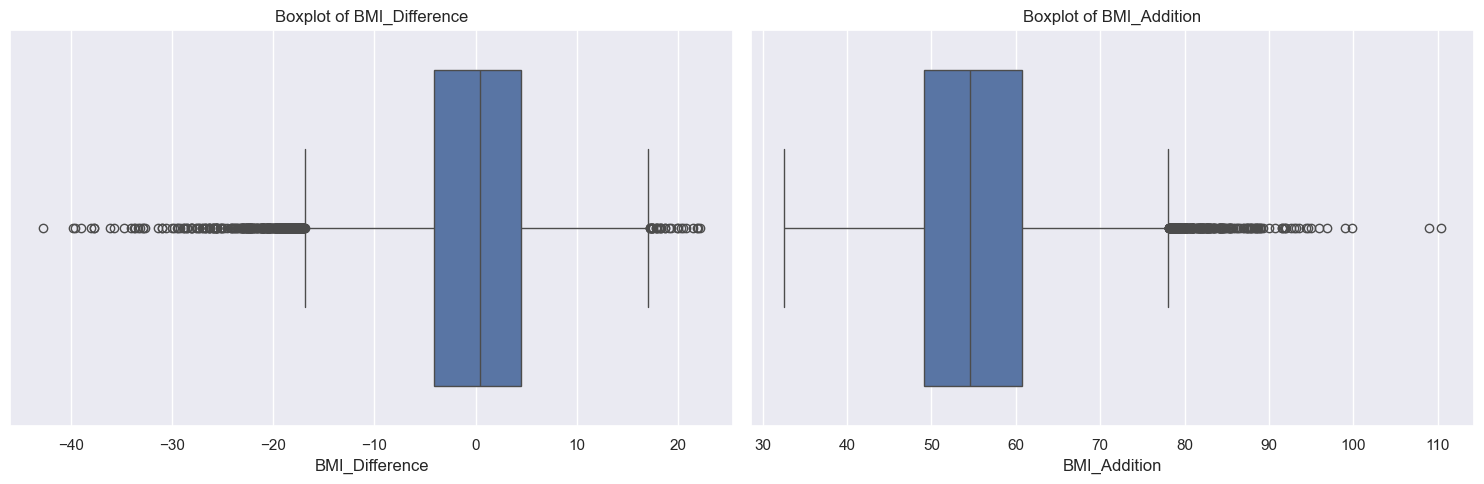

In [18]:
# boxplot
uv.plotBoxPlot(df, new, orientation='h')

##### BloodPH
- The normal blood pH range is indeed between 7.35 and 7.45. This slightly alkaline range is crucial for the proper functioning of enzymes and other biochemical reactions in the body.
    - A blood pH below 7.35 is considered acidic, and it can lead to a condition called acidosis. Acidosis can disrupt cellular functions and impair organ systems, particularly the cardiovascular and respiratory systems.
    - A blood pH above 7.45 is considered alkaline, and it can lead to a condition called alkalosis. Alkalosis can cause symptoms such as muscle twitching, hand tremors, and confusion.

In [19]:
# examine features
features = uf.getFeatureList(df, 'BloodPH')

               count     mean       std   min   25%   50%   75%   max
BloodPH_DON  15913.0  7.41826  0.067307  5.57  7.38  7.42  7.46  7.93

:::: NaN Count:
BloodPH_DON    213


In [20]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
213,BloodPH_DON,DDR:Blood PH:,DDR,2004-06-30,NaT,CLINICAL INFORMATION,NUM,,,PH_DON,Numeric,


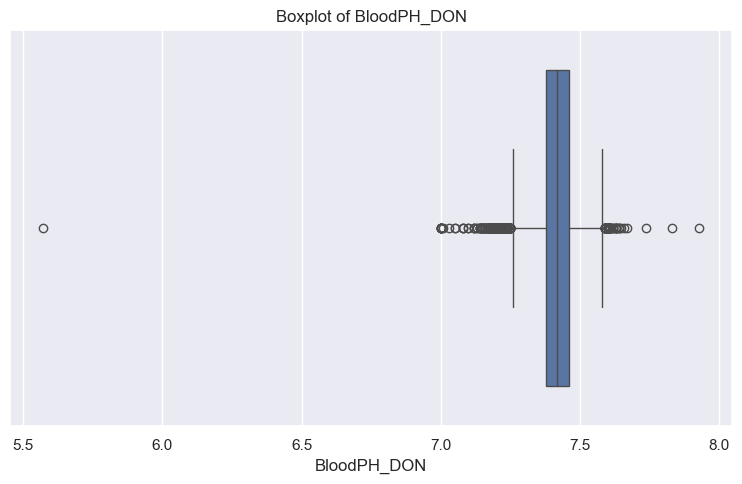

In [21]:
uv.plotBoxPlot(df, features, orientation='h')

##### BloodUreaNitrogenLevel
- Blood Urea Nitrogen (BUN) is a common blood test that measures the amount of urea nitrogen in the blood, which is a waste product formed from the breakdown of proteins.
    - Generally accepted range: 7 to 20 mg/dL (milligrams per deciliter).
    - Some sources report a slightly broader range of 6 to 24 mg/dL for adult men and 6 to 21 mg/dL for adult women. 

In [22]:
# examine features
features = uf.getFeatureList(df, 'BloodUreaNitrogenLevel')

                              count       mean       std  min   25%   50%   75%    max
BloodUreaNitrogenLevel_DON  15934.0  26.985286  21.77062  1.0  14.0  20.0  32.0  250.0

:::: NaN Count:
BloodUreaNitrogenLevel_DON    192


In [23]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
21,BloodUreaNitrogenLevel_DON,DECEASED DONOR-TERMINAL BLOOD UREA NITROGEN,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,BUN_DON,Numeric,


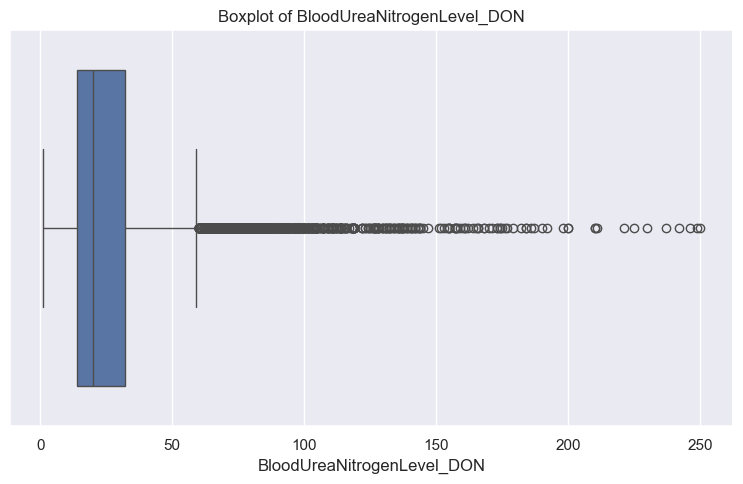

In [24]:
uv.plotBoxPlot(df, features, orientation='h')

##### CPRA
- CPRA (Calculated Panel Reactive Antibody) is a measure used to estimate the percentage of potential organ donors that a transplant candidate's immune system would react against due to preformed antibodies.
    - CPRA_Peak
        - The highest level of sensitization a patient has ever experienced.
        - Indicates the maximum percentage of potential donors that the patient's immune system would react against. This is crucial for understanding the patient's historical risk of rejection and their overall difficulty in finding a compatible donor.
    - CPRA_Recent
        - The most current level of sensitization.
        - Reflects the patient's current immune status and the percentage of potential donors they would currently react against. This is important for making immediate transplant decisions and assessing the current risk of rejection.
    - Key Differences:
        - Historical vs. Current: CPRA_Peak provides a historical maximum sensitization level, while CPRA_Recent gives the current sensitization level.
        - CPRA_Peak helps in understanding the worst-case scenario for donor compatibility, whereas CPRA_Recent is used for current transplant planning and risk assessment.

In [25]:
# examine features
features = uf.getFeatureList(df, 'CPRA')

                   count       mean        std  min  25%  50%   75%    max
CPRA_Peak_CAN    12221.0  14.897144  26.561462  0.0  0.0  0.0  19.0  100.0
CPRA_Recent_CAN  12234.0  11.228462  23.407934  0.0  0.0  0.0   7.0  100.0

:::: NaN Count:
CPRA_Peak_CAN      3905
CPRA_Recent_CAN    3892


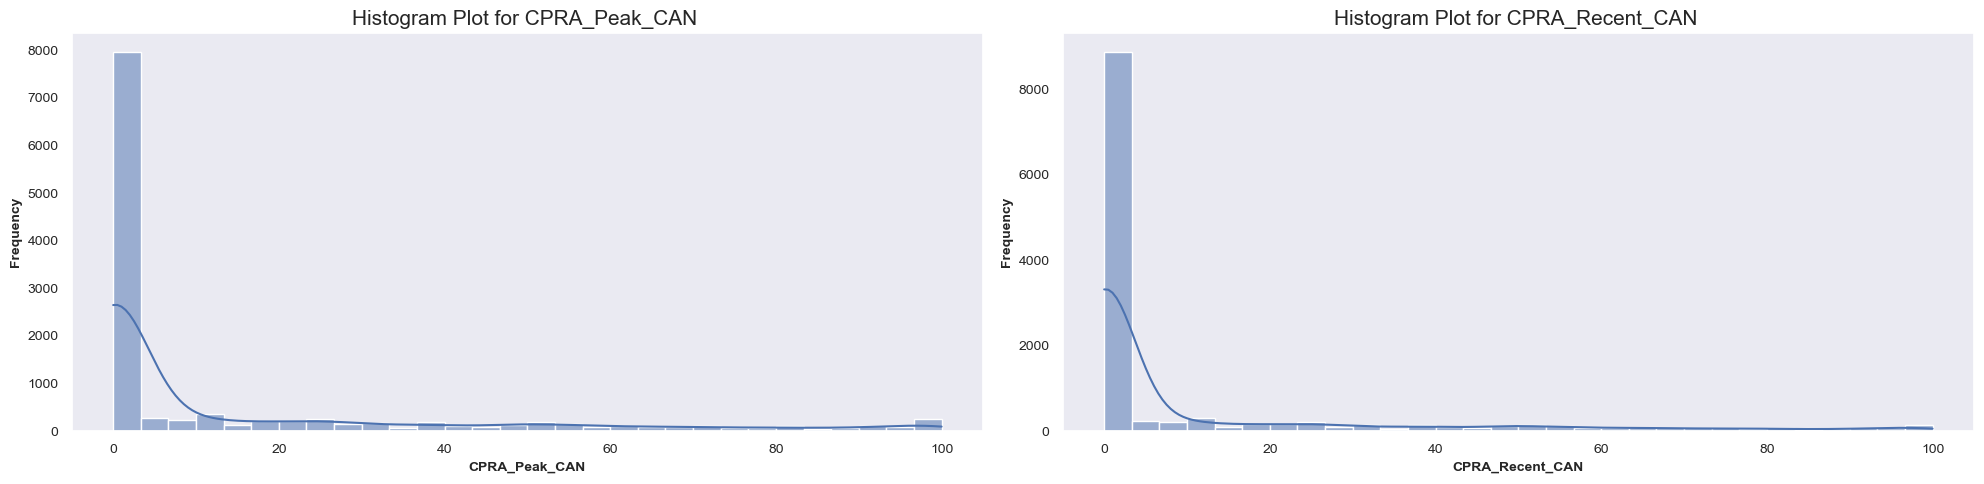

In [26]:
uv.histogramPlot(df, features)

##### A correlation of 0.90 indicates a high degree of similarity between the variables, though it's not a perfect one-to-one relationship. Creating an interaction term for highly correlated features can help capture the combined effect of these features in the model.

In [27]:
df[features].corr()

,CPRA_Peak_CAN,CPRA_Recent_CAN
CPRA_Peak_CAN,1.000000,0.901605
CPRA_Recent_CAN,0.901605,1.000000


In [28]:
# create new feature: add small constant to handle 0 values
df['PanelReactiveAntibody_CPRA_Interaction_CAN'] = (df.CPRA_Recent_CAN + 1e-5) * (df.CPRA_Peak_CAN + 1e-5)
# create new feature difference & addition between CPRA_Peak_CAN & CPRA_Recent_CAN
df['PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN'] = df.CPRA_Peak_CAN - df.CPRA_Recent_CAN
df['PanelReactiveAntibody_CPRA_Addition_CAN'] = df.CPRA_Peak_CAN + df.CPRA_Recent_CAN

# initialize list
new = ['PanelReactiveAntibody_CPRA_Interaction_CAN', 'PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN', 'PanelReactiveAntibody_CPRA_Addition_CAN']

# update dataframe
df_drop  = uf.insertIntoDataFrame(df_drop, features)
df_numeric = uf.insertIntoDataFrame(df_numeric, new)
df_new = uf.insertIntoDataFrame(df_new, new)
df_can = uf.insertIntoDataFrame(df_can, new)

In [29]:
df[(features + new)].corr()

,CPRA_Peak_CAN,CPRA_Recent_CAN,PanelReactiveAntibody_CPRA_Interaction_CAN,PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN,PanelReactiveAntibody_CPRA_Addition_CAN
CPRA_Peak_CAN,1.000000,0.901605,0.873162,0.472142,0.978144
CPRA_Recent_CAN,0.901605,1.000000,0.956444,0.044374,0.971840
PanelReactiveAntibody_CPRA_Interaction_CAN,0.873162,0.956444,1.000000,0.067446,0.935409
PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN,0.472142,0.044374,0.067446,1.000000,0.278532
PanelReactiveAntibody_CPRA_Addition_CAN,0.978144,0.971840,0.935409,0.278532,1.000000


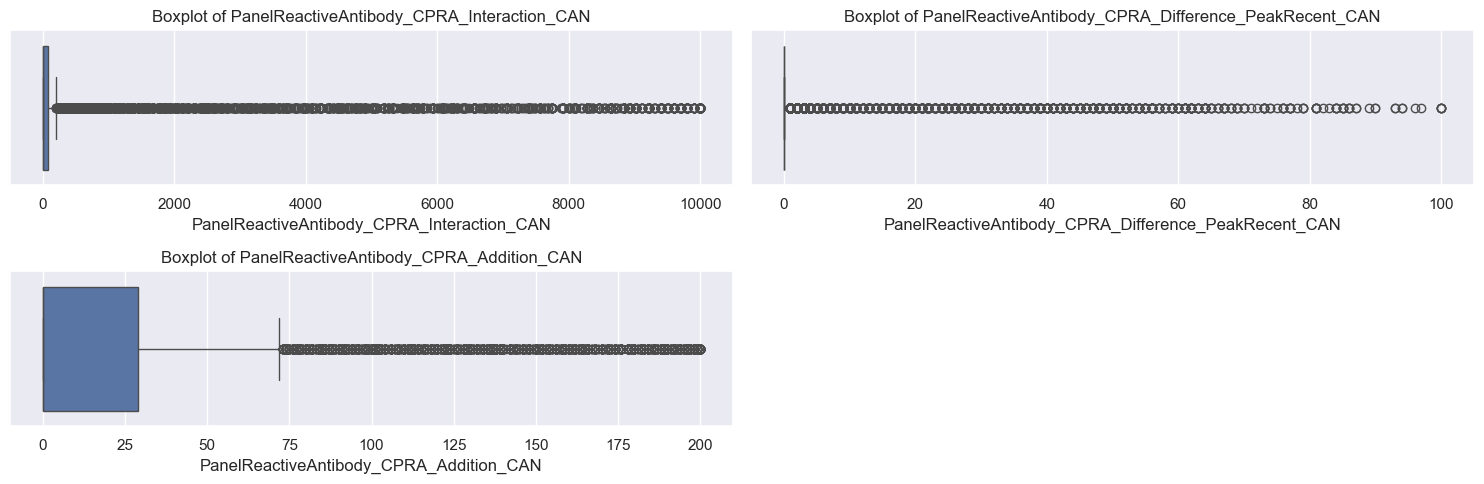

In [30]:
# boxplot
uv.plotBoxPlot(df, new, orientation='h')

##### Creatinine
- Creatinine levels can be affected by various health issues, including heart conditions. Generally, high creatinine levels are more common and often indicate that the kidneys are not functioning properly. This can be due to conditions such as chronic kidney disease, dehydration, or even heart failure. When the heart is not pumping efficiently, it can lead to reduced blood flow to the kidneys, causing an increase in creatinine levels.

In [31]:
# examine features
features = uf.getFeatureList(df, 'Creatinine')

                              count      mean       std   min   25%   50%   75%   max
CreatinineRegistration_CAN  16016.0  1.386274  1.011872  0.08  0.95  1.20  1.50  24.0
CreatinineTransplant_CAN    15708.0  1.379902  1.060986  0.06  0.94  1.19  1.50  37.0
Creatinine_DON              15934.0  1.576678  1.668662  0.04  0.75  1.00  1.53  19.0

:::: NaN Count:
CreatinineRegistration_CAN    110
CreatinineTransplant_CAN      418
Creatinine_DON                192


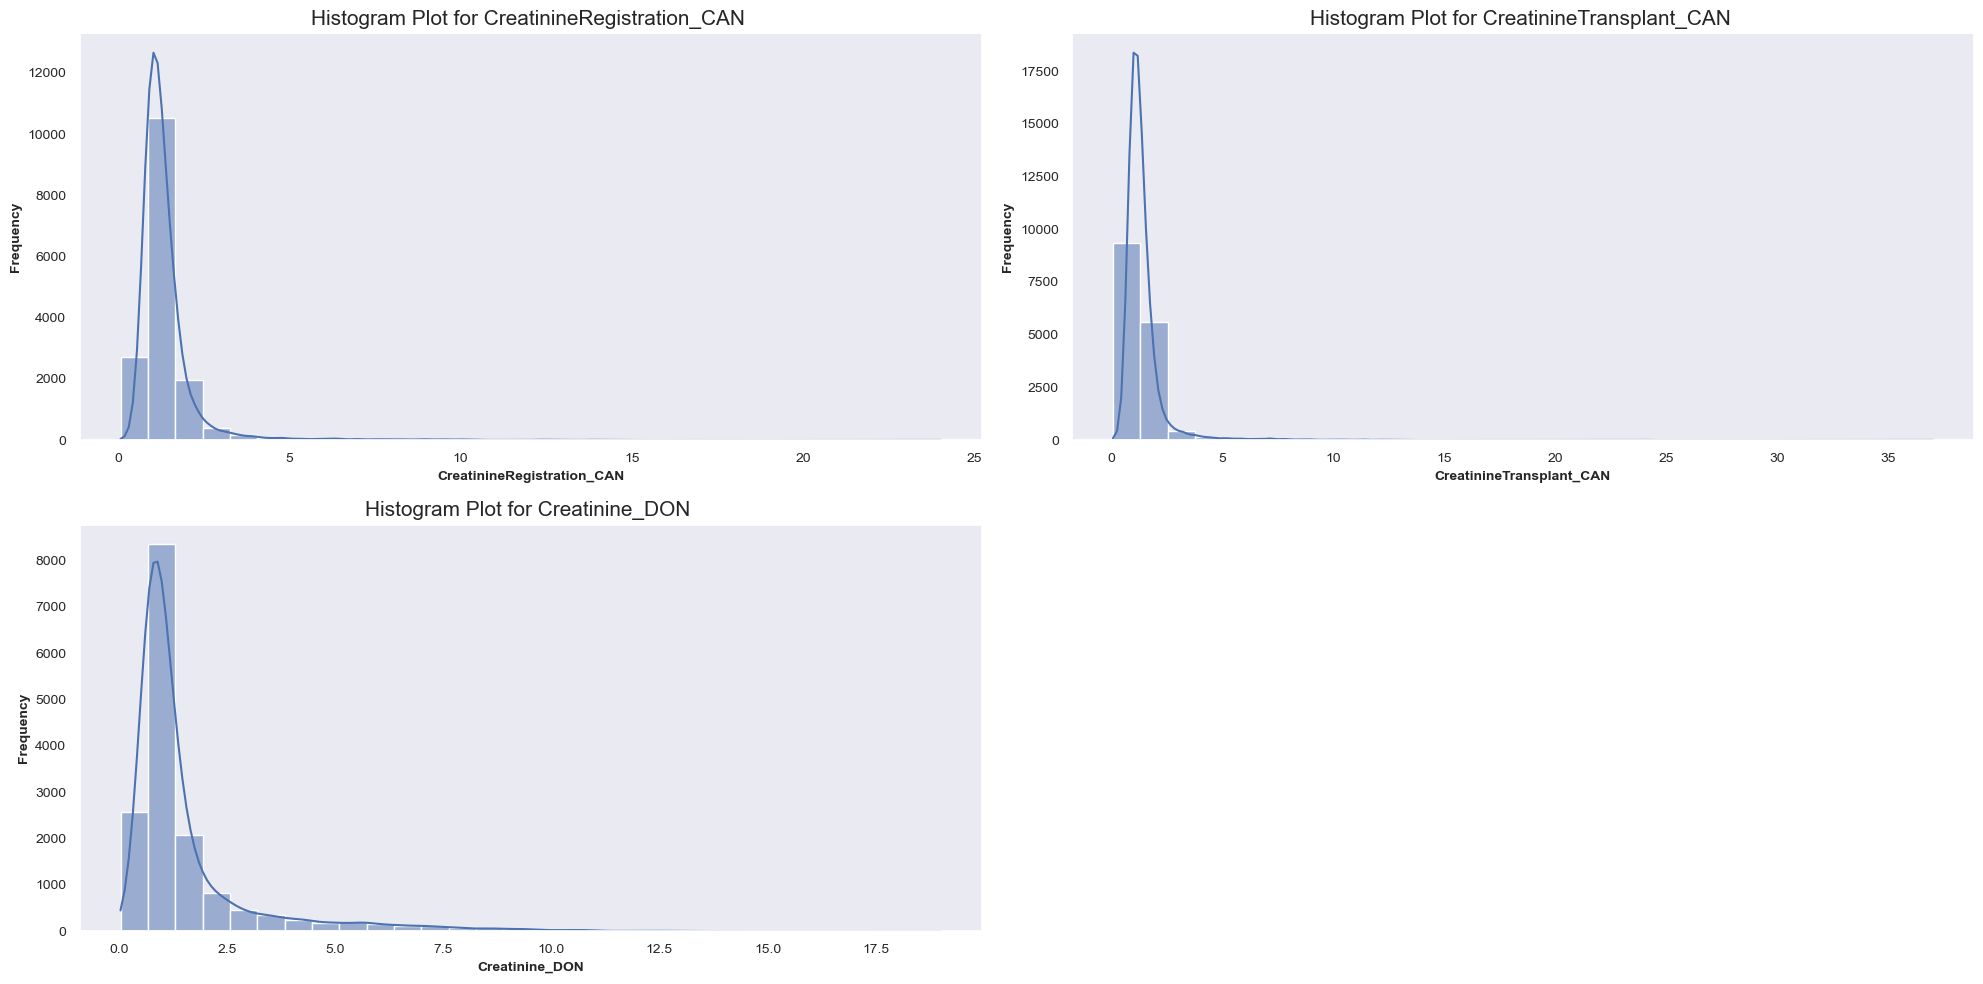

In [32]:
uv.histogramPlot(df, features)

In [33]:
df[features].corr()

,CreatinineRegistration_CAN,CreatinineTransplant_CAN,Creatinine_DON
CreatinineRegistration_CAN,1.000000,0.690318,-0.046011
CreatinineTransplant_CAN,0.690318,1.000000,-0.032917
Creatinine_DON,-0.046011,-0.032917,1.000000


In [34]:
# create new feature
df['Creatinine_Difference_CAN'] =  df.CreatinineRegistration_CAN - df.CreatinineTransplant_CAN
df['Creatinine_Addition_CAN'] =  df.CreatinineRegistration_CAN + df.CreatinineTransplant_CAN

# initialize list
new = ['Creatinine_Difference_CAN', 'Creatinine_Addition_CAN']

# update DataFrame
df_drop  = uf.insertIntoDataFrame(df_drop, features)
df_numeric =  uf.insertIntoDataFrame(df_numeric, new)
df_new =  uf.insertIntoDataFrame(df_new, new)
df_both = uf.insertIntoDataFrame(df_both, new)
df_can = uf.insertIntoDataFrame(df_can, new)

In [35]:
df[features + new].corr()

,CreatinineRegistration_CAN,CreatinineTransplant_CAN,Creatinine_DON,Creatinine_Difference_CAN,Creatinine_Addition_CAN
CreatinineRegistration_CAN,1.000000,0.690318,-0.046011,0.339019,0.915046
CreatinineTransplant_CAN,0.690318,1.000000,-0.032917,-0.446628,0.923499
Creatinine_DON,-0.046011,-0.032917,1.000000,-0.014522,-0.042654
Creatinine_Difference_CAN,0.339019,-0.446628,-0.014522,1.000000,-0.069245
Creatinine_Addition_CAN,0.915046,0.923499,-0.042654,-0.069245,1.000000


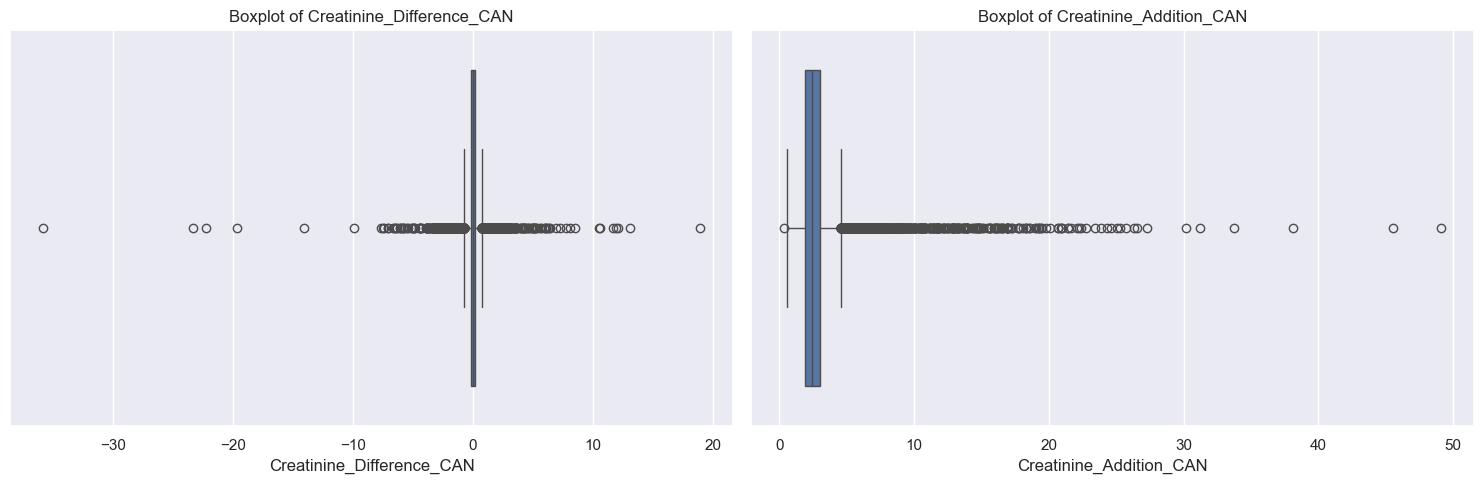

In [36]:
# boxplot
uv.plotBoxPlot(df, new, orientation='h')

##### DistanceFromDonorHospitaltoTXCenter

In [37]:
# examine features
features = uf.getFeatureList(df, 'DistanceFromDonorHospitaltoTXCenter')

                                       count        mean         std  min   25%    50%    75%     max
DistanceFromDonorHospitaltoTXCenter  16126.0  227.235272  228.375988  0.0  38.0  168.0  356.0  2215.0

:::: NaN Count:
DistanceFromDonorHospitaltoTXCenter    0


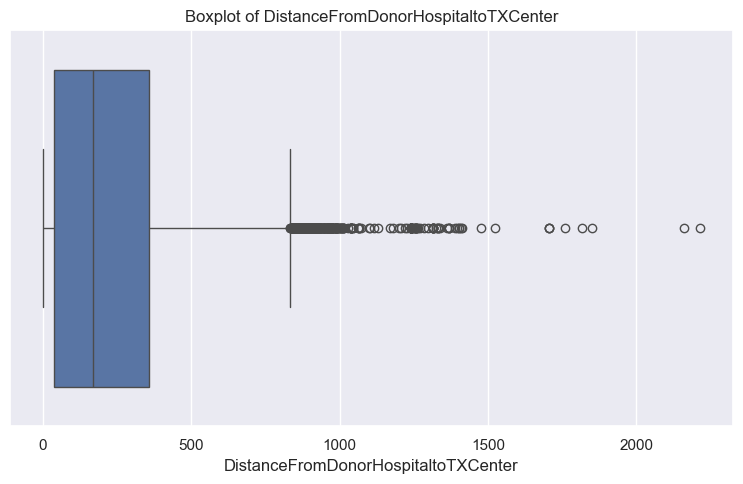

In [38]:
# boxplot
uv.plotBoxPlot(df, features, orientation='h')

##### HeightCm

In [39]:
# examine features
features = uf.getFeatureList(df, 'HeightCm')

                count        mean        std    min    25%    50%    75%    max
HeightCm_CAN  16126.0  173.590308  10.064621  124.0  167.6  174.7  180.3  213.4
HeightCm_DON  16126.0  173.878222   9.495651  115.0  167.6  175.0  180.3  213.0

:::: NaN Count:
HeightCm_CAN    0
HeightCm_DON    0


In [40]:
# create new feature
df['HeightCm_Difference'] = df.HeightCm_CAN - df.HeightCm_DON
df['HeightCm_Addition'] = df.HeightCm_CAN + df.HeightCm_DON

# initialize list
new = ['HeightCm_Difference', 'HeightCm_Addition']

# update dataframe
df_drop  = uf.insertIntoDataFrame(df_drop, features)
df_numeric = uf.insertIntoDataFrame(df_numeric, new)
df_new = uf.insertIntoDataFrame(df_new, new)
df_both = uf.insertIntoDataFrame(df_both, new)

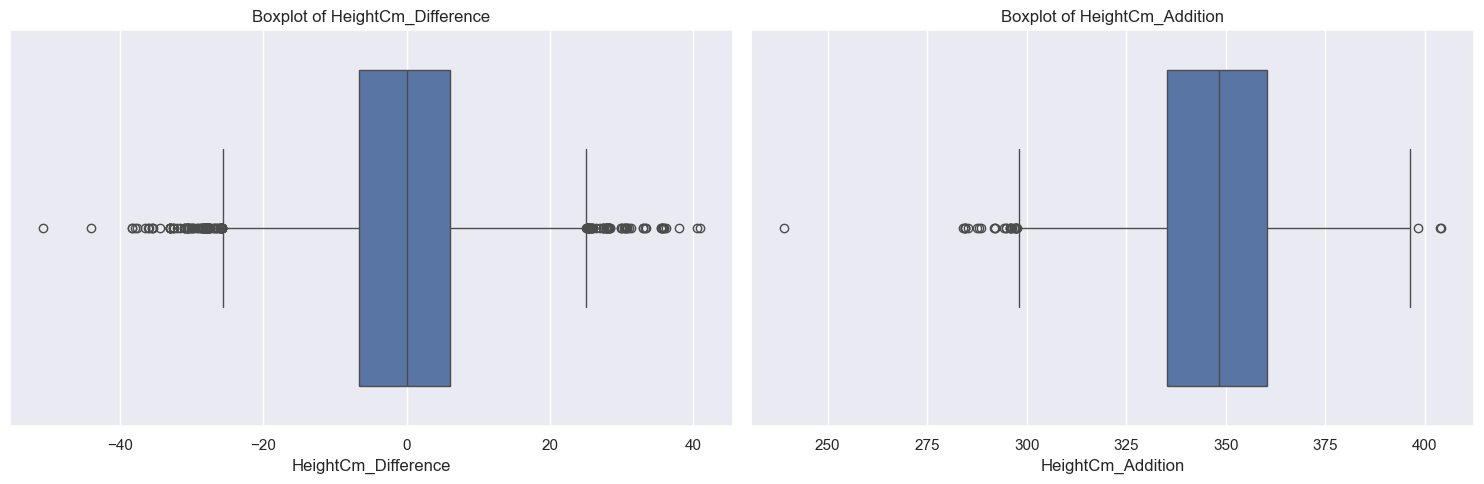

In [41]:
# boxplot
uv.plotBoxPlot(df, new, orientation='h')

##### Hematocrit
- Hematocrit is a blood test that measures the percentage of red blood cells (RBCs) in the total blood volume. It is an important indicator of overall health and can help diagnose various medical conditions.
    - Normal Hematocrit Ranges
        - Men: 38.3% to 48.6%
        - Women: 35.5% to 44.9% 

In [42]:
# examine features
features = uf.getFeatureList(df, 'Hematocrit')

                  count       mean       std  min   25%   50%   75%   max
Hematocrit_DON  15934.0  28.123641  4.914255  2.5  24.7  27.6  31.0  75.0

:::: NaN Count:
Hematocrit_DON    192


In [43]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
127,Hematocrit_DON,DDR:Hematocrit:,DDR,2004-06-30,NaT,CLINICAL INFORMATION,NUM,,,HEMATOCRIT_DON,Numeric,


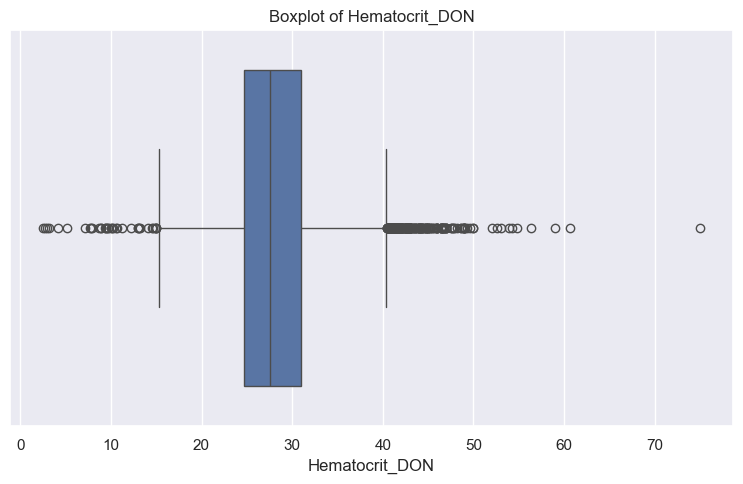

In [44]:
uv.plotBoxPlot(df, features, orientation='h')

##### Hemodynamics
- Hemodynamics refers to the study of blood flow and the forces involved in the circulatory system. It encompasses the physical principles governing blood movement through vessels and the heart, as well as the mechanics of blood flow and pressure regulation.
    - Here are some key ways hemodynamics can be affected:
        - Heart Failure: In heart failure, the heart's ability to pump blood effectively is compromised. This can lead to increased pressure in the heart and blood vessels, causing fluid buildup in the lungs and other tissues.
        - Valvular Heart Disease: Conditions like aortic stenosis or mitral regurgitation affect the flow of blood through the heart valves. This can lead to abnormal pressure gradients and changes in blood flow patterns, which can be detected through hemodynamic measurements.
        - Cardiomyopathies: These diseases affect the heart muscle, leading to changes in the heart's structure and function. Hemodynamic changes in cardiomyopathies can include altered cardiac output and increased filling pressures.
        - Hypertension: High blood pressure increases the workload on the heart, leading to changes in hemodynamics such as increased systemic vascular resistance and altered cardiac output1.
        - Pericardial Disease: Conditions like pericarditis or pericardial effusion can restrict the heart's movement, affecting hemodynamics by increasing pressures within the heart chambers and reducing cardiac output.

    - Hemodynamics:
        - Hemodynamics_SYS_CAN: Systolic blood pressure. (mmHg)
        - Hemodynamics_PA_DIA_CAN: Pulmonary artery diastolic pressure. (mmHg)
        - Hemodynamics_PA_MN_CAN: Pulmonary artery mean pressure. (mmHg)
        - Hemodynamics_PCW_CAN: Pulmonary capillary wedge pressure. (mmHg)
        - Hemodynamics_CO_CAN: Cardiac output. (L/min)

In [45]:
# examine features
features = uf.getFeatureList(df, 'Hemodynamics')

                                       count       mean        std   min    25%     50%   75%    max
HemodynamicsRegistration_CO_CAN      15240.0   4.244675   1.329615  0.45   3.31   4.100   5.0   14.4
HemodynamicsRegistration_PA_DIA_CAN  15528.0  20.181865   8.670702  0.00  14.00  20.000  26.0   91.0
HemodynamicsRegistration_PA_MN_CAN   15449.0  28.131113  10.162114  0.00  20.00  28.000  35.0   96.0
HemodynamicsRegistration_PCW_CAN     14667.0  18.748926   8.804931  0.00  12.00  18.000  25.0   50.0
HemodynamicsRegistration_SYS_CAN     15539.0  41.279426  14.194874  0.00  31.00  40.000  51.0  123.0
HemodynamicsTransplant_CO_CAN        15028.0   4.497855   1.455832  0.20   3.50   4.315   5.3   15.0
HemodynamicsTransplant_PA_DIA_CAN    15281.0  19.209149   8.484508  0.00  13.00  18.000  25.0  110.0
HemodynamicsTransplant_PA_MN_CAN     15140.0  26.995455   9.889409  0.00  20.00  26.000  34.0  110.0
HemodynamicsTransplant_PCW_CAN       14572.0  17.779592   8.664763  0.00  11.00  17.000  24

In [46]:
df[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.210110,-0.185994,-0.235137,-0.144777,0.519670,-0.110408,-0.094517,-0.118516,-0.068845
HemodynamicsRegistration_PA_DIA_CAN,-0.210110,1.000000,0.898484,0.831375,0.788621,-0.086018,0.562250,0.551506,0.506624,0.497385
HemodynamicsRegistration_PA_MN_CAN,-0.185994,0.898484,1.000000,0.846415,0.921249,-0.064285,0.539686,0.597562,0.515785,0.574632
HemodynamicsRegistration_PCW_CAN,-0.235137,0.831375,0.846415,1.000000,0.769674,-0.093017,0.510869,0.534629,0.600482,0.491107
HemodynamicsRegistration_SYS_CAN,-0.144777,0.788621,0.921249,0.769674,1.000000,-0.043744,0.480709,0.569772,0.466845,0.612464
HemodynamicsTransplant_CO_CAN,0.519670,-0.086018,-0.064285,-0.093017,-0.043744,1.000000,-0.215733,-0.177631,-0.216821,-0.144156
HemodynamicsTransplant_PA_DIA_CAN,-0.110408,0.562250,0.539686,0.510869,0.480709,-0.215733,1.000000,0.904631,0.819392,0.794765
HemodynamicsTransplant_PA_MN_CAN,-0.094517,0.551506,0.597562,0.534629,0.569772,-0.177631,0.904631,1.000000,0.833690,0.925554
HemodynamicsTransplant_PCW_CAN,-0.118516,0.506624,0.515785,0.600482,0.466845,-0.216821,0.819392,0.833690,1.000000,0.761784
HemodynamicsTransplant_SYS_CAN,-0.068845,0.497385,0.574632,0.491107,0.612464,-0.144156,0.794765,0.925554,0.761784,1.000000


In [47]:
# examine features
featuresR = uf.getFeatureList(df, 'HemodynamicsRegistration')

                                       count       mean        std   min    25%   50%   75%    max
HemodynamicsRegistration_CO_CAN      15240.0   4.244675   1.329615  0.45   3.31   4.1   5.0   14.4
HemodynamicsRegistration_PA_DIA_CAN  15528.0  20.181865   8.670702  0.00  14.00  20.0  26.0   91.0
HemodynamicsRegistration_PA_MN_CAN   15449.0  28.131113  10.162114  0.00  20.00  28.0  35.0   96.0
HemodynamicsRegistration_PCW_CAN     14667.0  18.748926   8.804931  0.00  12.00  18.0  25.0   50.0
HemodynamicsRegistration_SYS_CAN     15539.0  41.279426  14.194874  0.00  31.00  40.0  51.0  123.0

:::: NaN Count:
HemodynamicsRegistration_CO_CAN         886
HemodynamicsRegistration_PA_DIA_CAN     598
HemodynamicsRegistration_PA_MN_CAN      677
HemodynamicsRegistration_PCW_CAN       1459
HemodynamicsRegistration_SYS_CAN        587


In [48]:
df[featuresR].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.210110,-0.185994,-0.235137,-0.144777
HemodynamicsRegistration_PA_DIA_CAN,-0.210110,1.000000,0.898484,0.831375,0.788621
HemodynamicsRegistration_PA_MN_CAN,-0.185994,0.898484,1.000000,0.846415,0.921249
HemodynamicsRegistration_PCW_CAN,-0.235137,0.831375,0.846415,1.000000,0.769674
HemodynamicsRegistration_SYS_CAN,-0.144777,0.788621,0.921249,0.769674,1.000000


In [49]:
# create new feature: add small constant to handle 0 values
df['HemodynamicsRegistration_Interaction_CAN'] = (df.HemodynamicsRegistration_PA_DIA_CAN + 1e-5) * (df.HemodynamicsRegistration_PA_MN_CAN + 1e-5) * \
                                                 (df.HemodynamicsRegistration_PCW_CAN + 1e-5) * (df.HemodynamicsRegistration_SYS_CAN + 1e-5)

df['HemodynamicsRegistration_Addition_CAN'] = df.HemodynamicsRegistration_PA_DIA_CAN + df.HemodynamicsRegistration_PA_MN_CAN +  \
                                              df.HemodynamicsRegistration_PCW_CAN + df.HemodynamicsRegistration_SYS_CAN

# initialize list
new = ['HemodynamicsRegistration_Interaction_CAN', 'HemodynamicsRegistration_Addition_CAN']

In [50]:
# examine features
featuresT = uf.getFeatureList(df, 'HemodynamicsTransplant')

                                     count       mean        std  min   25%     50%   75%    max
HemodynamicsTransplant_CO_CAN      15028.0   4.497855   1.455832  0.2   3.5   4.315   5.3   15.0
HemodynamicsTransplant_PA_DIA_CAN  15281.0  19.209149   8.484508  0.0  13.0  18.000  25.0  110.0
HemodynamicsTransplant_PA_MN_CAN   15140.0  26.995455   9.889409  0.0  20.0  26.000  34.0  110.0
HemodynamicsTransplant_PCW_CAN     14572.0  17.779592   8.664763  0.0  11.0  17.000  24.0   50.0
HemodynamicsTransplant_SYS_CAN     15289.0  39.632926  13.726242  0.0  29.0  38.000  48.0  158.0

:::: NaN Count:
HemodynamicsTransplant_CO_CAN        1098
HemodynamicsTransplant_PA_DIA_CAN     845
HemodynamicsTransplant_PA_MN_CAN      986
HemodynamicsTransplant_PCW_CAN       1554
HemodynamicsTransplant_SYS_CAN        837


In [51]:
df[featuresT].corr()

,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsTransplant_CO_CAN,1.000000,-0.215733,-0.177631,-0.216821,-0.144156
HemodynamicsTransplant_PA_DIA_CAN,-0.215733,1.000000,0.904631,0.819392,0.794765
HemodynamicsTransplant_PA_MN_CAN,-0.177631,0.904631,1.000000,0.833690,0.925554
HemodynamicsTransplant_PCW_CAN,-0.216821,0.819392,0.833690,1.000000,0.761784
HemodynamicsTransplant_SYS_CAN,-0.144156,0.794765,0.925554,0.761784,1.000000


In [52]:
# create new feature: add small constant to handle 0 values
df['HemodynamicsTransplant_Interaction_CAN'] = (df.HemodynamicsTransplant_PA_DIA_CAN + 1e-5) * (df.HemodynamicsTransplant_PA_MN_CAN + 1e-5) * \
                                                 (df.HemodynamicsTransplant_PCW_CAN + 1e-5) * (df.HemodynamicsTransplant_SYS_CAN + 1e-5)

df['HemodynamicsTransplant_Addition_CAN'] = df.HemodynamicsTransplant_PA_DIA_CAN + df.HemodynamicsTransplant_PA_MN_CAN +  \
                                            df.HemodynamicsTransplant_PCW_CAN + df.HemodynamicsTransplant_SYS_CAN

# add list
new.extend(['HemodynamicsTransplant_Interaction_CAN','HemodynamicsTransplant_Addition_CAN'])

In [53]:
# difference between Registration & Transplant
df['Hemodynamics_Difference_CO_RT_CAN'] = df.HemodynamicsRegistration_CO_CAN - df.HemodynamicsTransplant_CO_CAN
df['Hemodynamics_Difference_PA_DIA_RT_CAN'] = df.HemodynamicsRegistration_PA_DIA_CAN - df.HemodynamicsTransplant_PA_DIA_CAN
df['Hemodynamics_Difference_PA_MN_RT_CAN'] = df.HemodynamicsRegistration_PA_MN_CAN - df.HemodynamicsTransplant_PA_MN_CAN
df['Hemodynamics_Difference_PCW_RT_CAN'] = df.HemodynamicsRegistration_PA_MN_CAN - df.HemodynamicsTransplant_PCW_CAN
df['Hemodynamics_Difference_SYS_RT_CAN'] = df.HemodynamicsRegistration_SYS_CAN - df.HemodynamicsTransplant_SYS_CAN

# create new feature: add small constant to handle 0 values
df['Hemodynamics_Interaction_Difference_CAN'] = (df.Hemodynamics_Difference_PA_DIA_RT_CAN + 1e-5) * (df.Hemodynamics_Difference_PA_MN_RT_CAN + 1e-5) * \
                                                 (df.Hemodynamics_Difference_PCW_RT_CAN + 1e-5) * (df.Hemodynamics_Difference_SYS_RT_CAN + 1e-5)

df['Hemodynamics_Addition_Difference_CAN'] = df.Hemodynamics_Difference_PA_DIA_RT_CAN +  df.Hemodynamics_Difference_PA_MN_RT_CAN +  \
                                             df.Hemodynamics_Difference_PCW_RT_CAN +  df.Hemodynamics_Difference_SYS_RT_CAN

# initialize list
featuresD = ['Hemodynamics_Difference_CO_RT_CAN','Hemodynamics_Difference_PA_DIA_RT_CAN', 'Hemodynamics_Difference_PA_MN_RT_CAN',
             'Hemodynamics_Difference_PCW_RT_CAN','Hemodynamics_Difference_SYS_RT_CAN', 'Hemodynamics_Interaction_Difference_CAN', 'Hemodynamics_Addition_Difference_CAN']

# add list
new.extend(featuresD)

In [54]:
df[featuresD].corr()

,Hemodynamics_Difference_CO_RT_CAN,Hemodynamics_Difference_PA_DIA_RT_CAN,Hemodynamics_Difference_PA_MN_RT_CAN,Hemodynamics_Difference_PCW_RT_CAN,Hemodynamics_Difference_SYS_RT_CAN,Hemodynamics_Interaction_Difference_CAN,Hemodynamics_Addition_Difference_CAN
Hemodynamics_Difference_CO_RT_CAN,1.000000,-0.250694,-0.235200,-0.229338,-0.204823,-0.019925,-0.254692
Hemodynamics_Difference_PA_DIA_RT_CAN,-0.250694,1.000000,0.844606,0.727134,0.735390,0.113554,0.885510
Hemodynamics_Difference_PA_MN_RT_CAN,-0.235200,0.844606,1.000000,0.820816,0.888919,0.134385,0.966067
Hemodynamics_Difference_PCW_RT_CAN,-0.229338,0.727134,0.820816,1.000000,0.743735,0.160324,0.891478
Hemodynamics_Difference_SYS_RT_CAN,-0.204823,0.735390,0.888919,0.743735,1.000000,0.117541,0.931968
Hemodynamics_Interaction_Difference_CAN,-0.019925,0.113554,0.134385,0.160324,0.117541,1.000000,0.142399
Hemodynamics_Addition_Difference_CAN,-0.254692,0.885510,0.966067,0.891478,0.931968,0.142399,1.000000


In [55]:
# remove CO
featuresR.remove('HemodynamicsRegistration_CO_CAN')
featuresT.remove('HemodynamicsTransplant_CO_CAN')
# update DataFrame
df_drop  = uf.insertIntoDataFrame(df_drop, featuresR)
df_drop  = uf.insertIntoDataFrame(df_drop, featuresT)
df_numeric =  uf.insertIntoDataFrame(df_numeric, new)
df_new =  uf.insertIntoDataFrame(df_new, new)
df_can = uf.insertIntoDataFrame(df_can, new)

##### IschemicTimeHour
- Ischemic time refers to the period during which an organ or tissue is deprived of blood supply and, consequently, oxygen. This concept is crucial in various medical contexts, particularly in transplantation and acute medical conditions like strokes and heart attacks.
    - Importance in Transplantation
        - Kidney: Optimal cold ischemic time is less than 20 hours, with suboptimal times extending beyond 36 hours.
        - Liver: Optimal cold ischemic time is less than 10 hours.
        - Heart: Optimal cold ischemic time is less than 4 hours.
        - Lung: Optimal cold ischemic time is less than 8 hours1.
    - Clinical Implications
        - Prolonged ischemic times can lead to greater tissue damage and delayed organ function.
        - Shorter ischemic times are associated with better transplant outcomes and long-term success

In [56]:
# examine features
features = uf.getFeatureList(df, 'IschemicTimeHour_DON')

                        count      mean       std  min  25%  50%  75%   max
IschemicTimeHour_DON  15630.0  3.294421  1.088193  0.3  2.6  3.3  3.9  12.0

:::: NaN Count:
IschemicTimeHour_DON    496


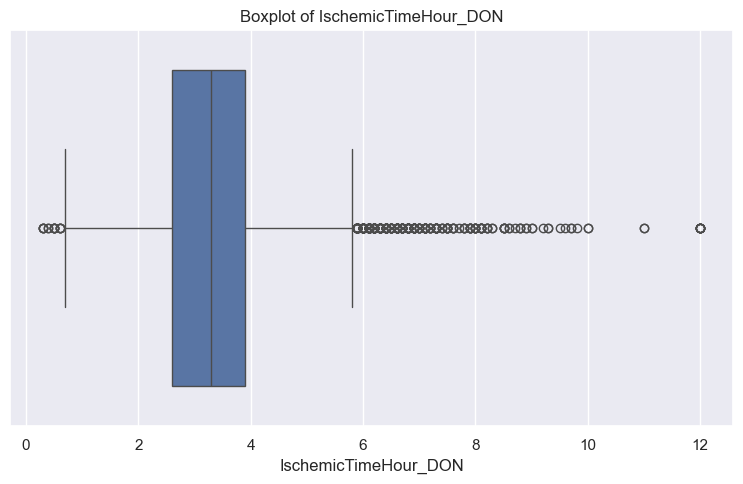

In [57]:
uv.plotBoxPlot(df, features)

##### LV_EjectionFractionPercent
- Left ventricular ejection fraction (LVEF) is a critical measurement used to assess the function of the heart, particularly in the context of organ donation and transplantation. It represents the percentage of blood that is pumped out of the left ventricle with each heartbeat.
    - Normal LVEF: Typically, a normal ejection fraction is between 50% and 70%.
    - Mildly Reduced LVEF: Values between 41% and 49% may indicate mild dysfunction.
    - Reduced LVEF: An LVEF less than 40% is often considered significantly reduced and may be a contraindication for organ donation, although recent studies suggest that donor hearts with reduced LVEF can still be viable for transplantation under certain conditions.

In [58]:
# examine features
features = uf.getFeatureList(df, 'LV_EjectionFractionPercent')

                                  count       mean       std   min   25%   50%   75%   max
LV_EjectionFractionPercent_DON  16109.0  61.614332  6.598243  10.0  56.0  60.0  65.0  96.0

:::: NaN Count:
LV_EjectionFractionPercent_DON    17


In [59]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
195,LV_EjectionFractionPercent_DON,DECEASED DONOR LV EJECTION FRACTION %,DDR,1999-10-25,NaT,HEART DONOR'S CARDIAC FUNCTION,NUM,,,LV_EJECT,Numeric,


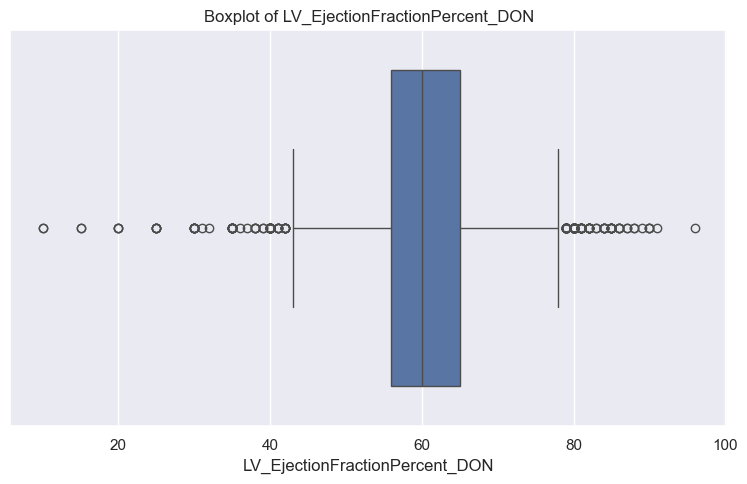

In [60]:
uv.plotBoxPlot(df, features, orientation='h')

##### Level_SGOT
- SGOT (AST) and ALT (DON) are enzymes that are commonly measured to assess liver health:
    - SGOT (AST): Also known as aspartate aminotransferase (AST), this enzyme is found in various tissues, including the liver, heart, muscles, and kidneys. It plays a role in amino acid metabolism. Elevated levels of AST in the blood can indicate liver damage, heart problems, or muscle injury.
        - Conservative normal range of 8 to 45 units/L for healthy individuals. 
    - SGOT (ALT): Also known as alanine aminotransferase (ALT), this enzyme is primarily found in the liver. It helps convert proteins into energy for liver cells. High levels of ALT are more specific to liver damage compared to AST.
        - The typical normal range for ALT is approximately 7 to 56 units per liter (U/L) of serum. However, ranges may vary slightly between laboratories. 

In [61]:
# examine features
features = uf.getFeatureList(df, 'Level_SGOT')

                      count        mean         std  min   25%   50%   75%      max
Level_SGOT_ALT_DON  15933.0  121.348710  471.772351  3.0  24.0  42.0  88.0  44117.0
Level_SGOT_AST_DON  15933.0  100.836377  299.238169  0.4  25.0  44.0  88.0  10196.0

:::: NaN Count:
Level_SGOT_ALT_DON    193
Level_SGOT_AST_DON    193


In [62]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
259,Level_SGOT_AST_DON,DECEASED DONOR-TERMINAL SGOT/AST,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,SGOT_DON,Numeric,
260,Level_SGOT_ALT_DON,DECEASED DONOR-TERMINAL SGPT/ALT,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,SGPT_DON,Numeric,


In [63]:
df[features].corr()

,Level_SGOT_ALT_DON,Level_SGOT_AST_DON
Level_SGOT_ALT_DON,1.000000,0.483167
Level_SGOT_AST_DON,0.483167,1.000000


##### Addition can help you understand the combined enzyme activity. Capturing the overall level of these enzymes might be helpful.

In [64]:
# new feature
df['Level_SGOT_Difference_AltAst_DON'] = df.Level_SGOT_ALT_DON - df.Level_SGOT_AST_DON
df['Level_SGOT_Addition_DON'] = df.Level_SGOT_ALT_DON + df.Level_SGOT_AST_DON

# initialize list
new = ['Level_SGOT_Difference_AltAst_DON', 'Level_SGOT_Addition_DON']

# update DataFrame
df_drop  = uf.insertIntoDataFrame(df_drop, features)
df_numeric =  uf.insertIntoDataFrame(df_numeric, new)
df_new =  uf.insertIntoDataFrame(df_new, new)
df_both = uf.insertIntoDataFrame(df_both, new)
df_don = uf.insertIntoDataFrame(df_don, new)

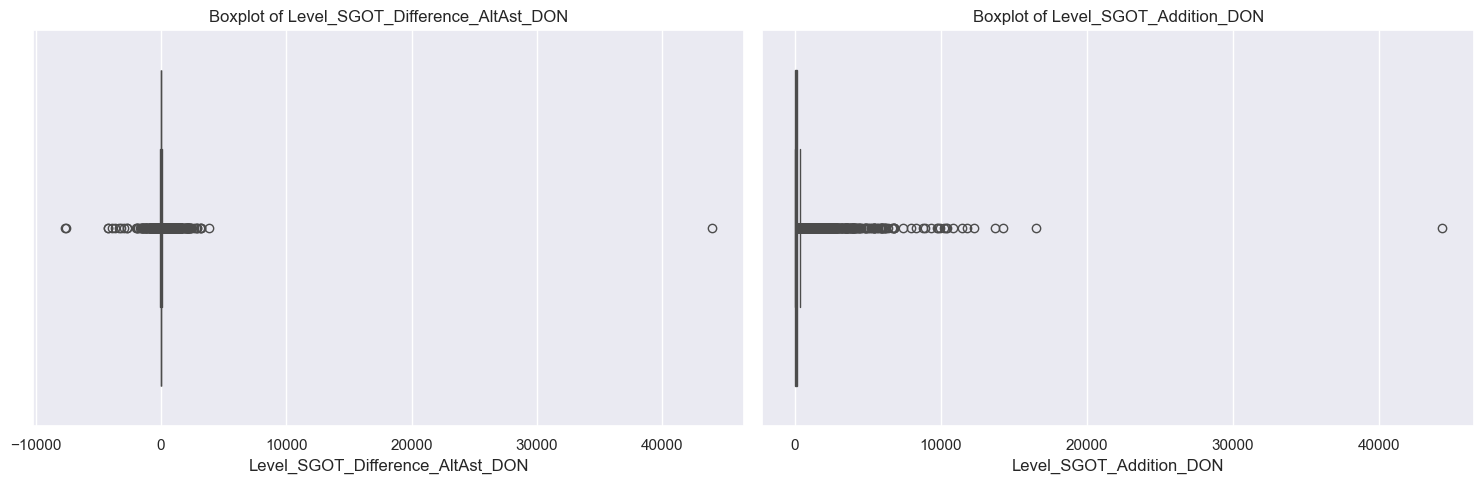

In [65]:
uv.plotBoxPlot(df, new, orientation='h')

##### LungPO2
    - Remove:
        - LungPO2_Done_DON 
- Lung PO2 (Partial Pressure of Oxygen) is a measure of the pressure exerted by oxygen in the lungs. It is an important indicator of how well oxygen is being transferred from the air in the lungs to the blood. The value of PO2 is typically measured in millimeters of mercury (mmHg) and provides insight into the efficiency of the respiratory system. In clinical and transplant contexts, particularly with donors, it helps assess the oxygenation status of the donor’s lungs, which is critical when evaluating organs for transplantation. `LungPO2_DON`: PO2 on 100% oxygen refers to the partial pressure of oxygen in arterial blood when a patient is breathing 100% oxygen.

- The Fraction of Inspired Oxygen (Lung FIO2) refers to the concentration of oxygen in the air that is being inhaled by a patient. It is a critical parameter in managing patients with respiratory distress and is often expressed as a percentage or as a decimal. `LungPO2_FIO2_DON`: Lung pO2 on FiO2 refers to the partial pressure of oxygen in arterial blood (PaO2) in relation to the fraction of inspired oxygen (FiO2).
    - Normal Range for FIO2
        - Room Air: The FIO2 in room air is approximately 21% or 0.21 as a decimal.
    - Supplemental Oxygen:
        - Low-Flow Oxygen Therapy: FIO2 can range from about 24% (0.24) to 40% (0.40), depending on the delivery device (e.g., nasal cannula, simple face mask).
        - High-Flow Oxygen Therapy: FIO2 can be set between 40% (0.40) and 100% (1.0), especially in more controlled environments like intensive care units.<br><br>

- The partial pressure of oxygen (PO2) levels can significantly impact heart conditions.
    - Low PO2 levels, or hypoxemia, can lead to insufficient oxygen in the blood, which stresses the heart as it works harder to supply oxygen to tissues1. This can exacerbate conditions like congestive heart failure.
    - To compensate for low oxygen levels, the heart may increase its rate and output, which can strain the heart over time2.
    - Even if blood oxygenation appears normal, poor cardiac output can result in inadequate oxygen delivery to tissues, leading to hypoxia. This can cause symptoms like chest pain, shortness of breath, and fatigue.
    - Interestingly, higher bilirubin levels, which can be influenced by PO2, have been associated with a reduced risk of cardiovascular diseases due to their antioxidant properties.

In [66]:
# examine features
features = uf.getFeatureList(df, 'LungPO2')

                    count unique      top   freq        mean        std   min    25%    50%    75%    max
LungPO2_DON       15925.0    NaN      NaN    NaN  283.164678  160.90498  12.0  130.0  266.0  430.0  698.0
LungPO2_Done_DON    16126      1  Missing  16126         NaN        NaN   NaN    NaN    NaN    NaN    NaN
LungPO2_FIO2_DON  15867.0    NaN      NaN    NaN   82.398374  25.355015   6.0   60.0  100.0  100.0  100.0

:::: NaN Count:
LungPO2_DON         201
LungPO2_Done_DON      0
LungPO2_FIO2_DON    259


In [67]:
df.LungPO2_Done_DON.value_counts(dropna=False)

LungPO2_Done_DON
Missing    16126
No             0
Yes            0
Name: count, dtype: int64

In [68]:
# remove feature
removeCols.extend(['LungPO2_Done_DON'])
features.remove('LungPO2_Done_DON')

In [69]:
df[features].corr()

,LungPO2_DON,LungPO2_FIO2_DON
LungPO2_DON,1.000000,0.630873
LungPO2_FIO2_DON,0.630873,1.000000


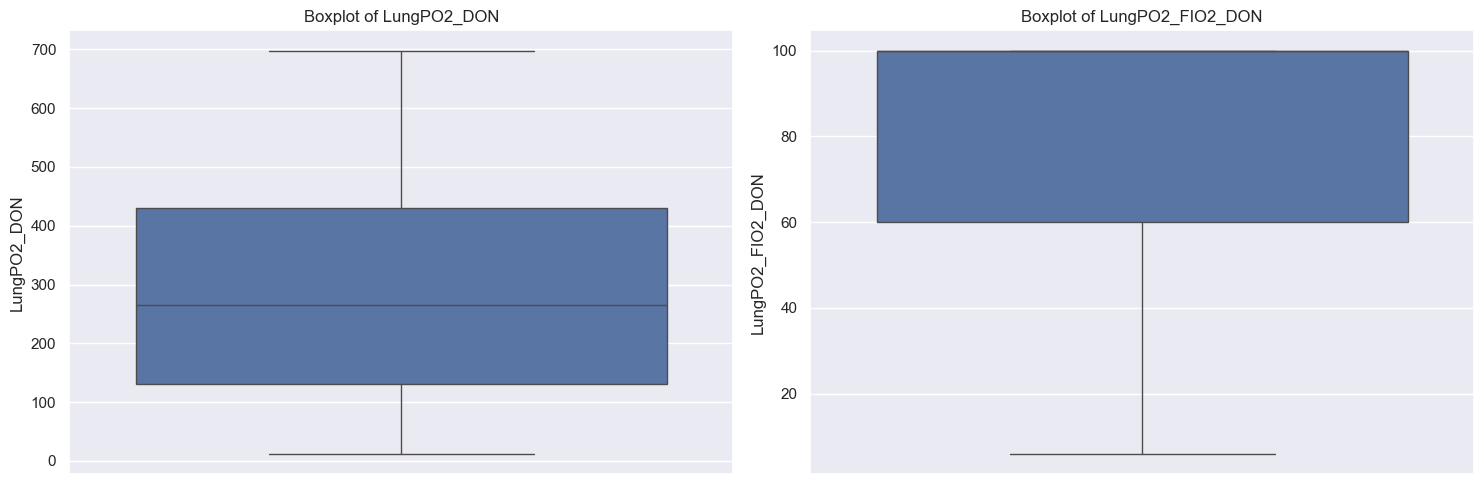

In [70]:
uv.plotBoxPlot(df, features, orientation='v')

##### OrganRecovery
- Normal `PCO2` Levels: The normal range for arterial blood `PCO2` is 35 to 45 mmHg (millimeters of mercury) or 4.7 to 6.0 kPa

In [71]:
# examine features
features = uf.getFeatureList(df, 'OrganRecovery')

                          count       mean       std   min   25%   50%   75%    max
OrganRecovery_PCO2_DON  15909.0  39.239164  7.029899  10.1  35.0  38.7  43.0  106.0

:::: NaN Count:
OrganRecovery_PCO2_DON    217


In [72]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
208,OrganRecovery_PCO2_DON,DDR:pCO2:,DDR,2004-06-30,NaT,ORGAN RECOVERY,NUM,,,PCO2_DON,Numeric,Maintaining appropriate PCO2 levels is crucial for preserving organ function and optimizing outcomes in transplantation.


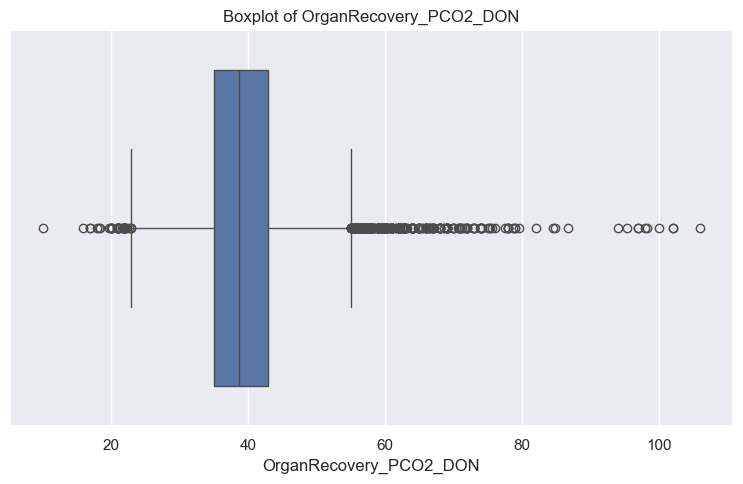

In [73]:
uv.plotBoxPlot(df, features, orientation='h')

##### Total Bilirubin
- Heart conditions can indeed influence total bilirubin levels, though the relationship is complex. Generally, higher bilirubin levels have been associated with a reduced risk of cardiovascular diseases (CVD). This is because bilirubin has antioxidant properties that may protect against oxidative stress and inflammation, which are key factors in the development of CVD. However, certain heart conditions, especially those that affect liver function or blood flow, could potentially lead to changes in bilirubin levels. For example, congestive heart failure can cause liver congestion, which might impair the liver's ability to process bilirubin, potentially leading to elevated levels.
- Bilirubin is a clinical measurement that evaluates the combined levels of direct (conjugated) and indirect (unconjugated) bilirubin in the blood. It is an important diagnostic marker for liver function, bile duct health, and conditions like jaundice.

In [74]:
# examine features
features = uf.getFeatureList(df, 'Bilirubin')

                                count      mean       std  min  25%  50%  75%   max
TerminalTotalBilirubin_DON    15933.0  1.037188  1.467089  0.0  0.5  0.7  1.1  45.4
TotalBilirubinTransplant_CAN  15696.0  1.002722  1.921291  0.1  0.5  0.7  1.1  80.0

:::: NaN Count:
TerminalTotalBilirubin_DON      193
TotalBilirubinTransplant_CAN    430


In [75]:
# new feature
df['TotalBilirubin_Difference'] = df.TotalBilirubinTransplant_CAN - df.TerminalTotalBilirubin_DON
df['TotalBilirubin_Addition'] = df.TotalBilirubinTransplant_CAN + df.TerminalTotalBilirubin_DON

# initialize list
new = ['TotalBilirubin_Difference','TotalBilirubin_Addition']

# update DataFrame
df_drop  = uf.insertIntoDataFrame(df_drop, features)
df_numeric =  uf.insertIntoDataFrame(df_numeric, new)
df_new =  uf.insertIntoDataFrame(df_new, new)
df_both = uf.insertIntoDataFrame(df_both, new)

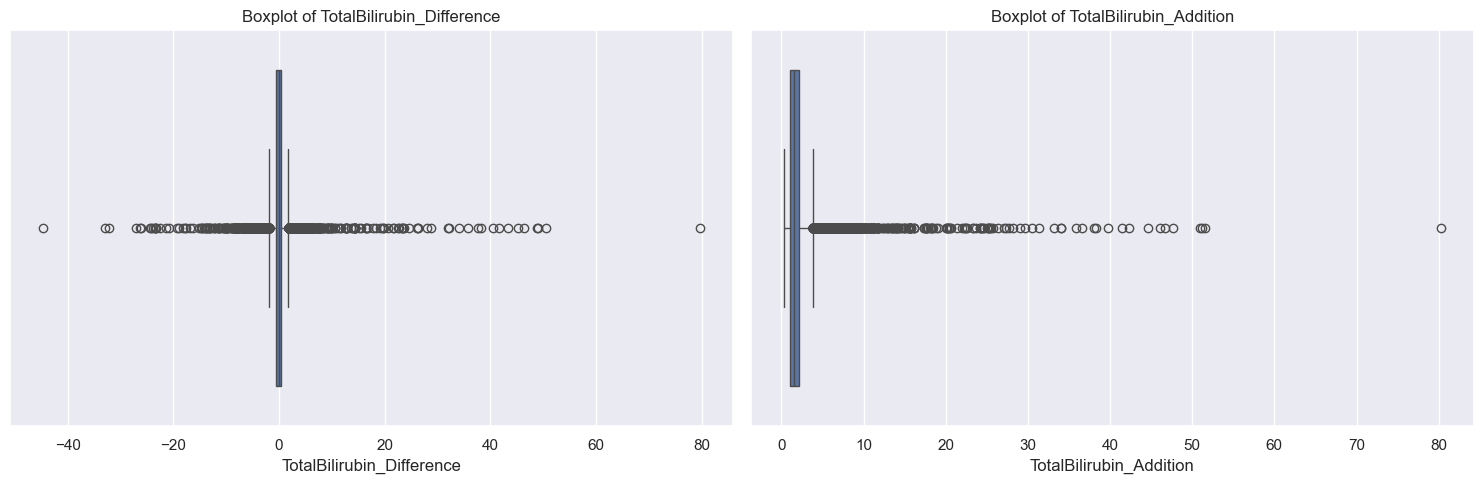

In [76]:
uv.plotBoxPlot(df, new, orientation='h')

##### TotalDayWaitList

In [77]:
# examine features
features = uf.getFeatureList(df, 'TotalDayWaitList')

                        count        mean         std  min   25%   50%    75%     max
TotalDayWaitList_CAN  16126.0  140.163277  229.090503  0.0  13.0  44.0  163.0  2078.0

:::: NaN Count:
TotalDayWaitList_CAN    0


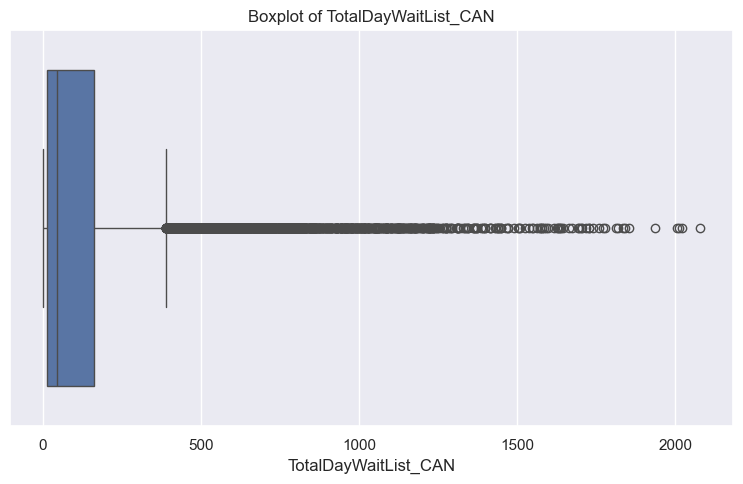

In [78]:
uv.plotBoxPlot(df, features, orientation='h')

##### WeightKg

In [79]:
# examine features
features = uf.getFeatureList(df, 'WeightKg')

                count       mean        std   min   25%   50%   75%    max
WeightKg_CAN  16121.0  83.545630  18.186947  32.5  70.6  82.6  95.7  159.1
WeightKg_DON  16125.0  83.932025  19.742471  23.2  70.0  81.0  95.0  196.9

:::: NaN Count:
WeightKg_CAN    5
WeightKg_DON    1


In [80]:
# new feature
df['WeightKg_Difference_CanDon'] = df.WeightKg_CAN - df.WeightKg_DON
df['WeightKg_Addition'] = df.WeightKg_CAN + df.WeightKg_DON

# initialize list
new = ['WeightKg_Difference_CanDon', 'WeightKg_Addition']

# update DataFrame
df_drop  = uf.insertIntoDataFrame(df_drop, features)
df_numeric =  uf.insertIntoDataFrame(df_numeric, new)
df_new =  uf.insertIntoDataFrame(df_new, new)
df_both = uf.insertIntoDataFrame(df_both, new)

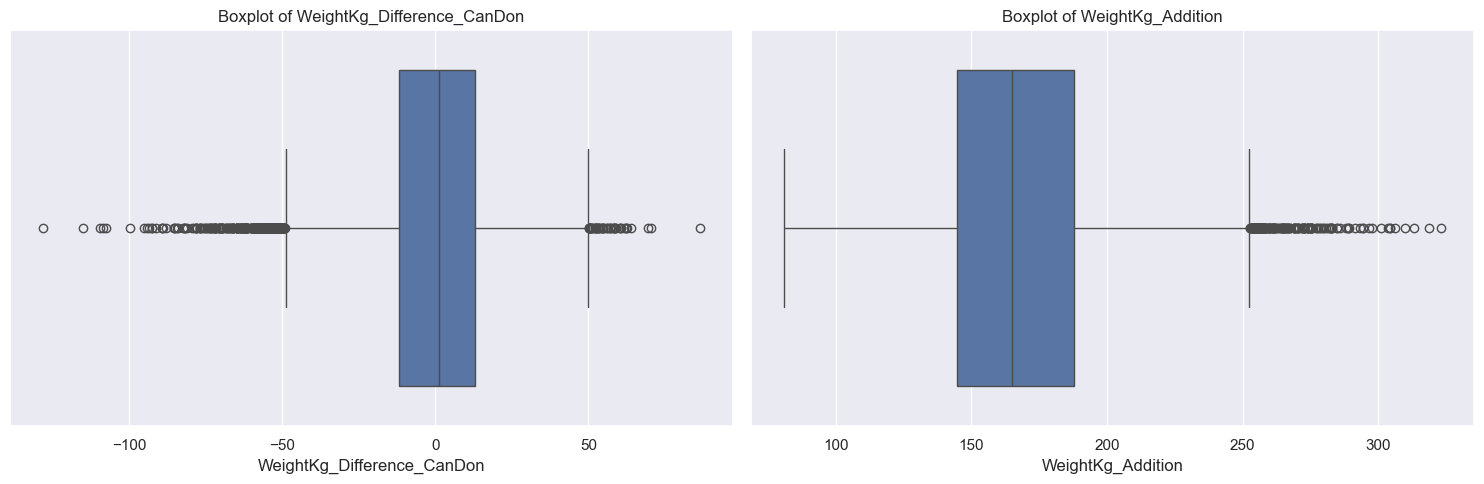

In [81]:
uv.plotBoxPlot(df, new, orientation='h')

### Nominal

In [82]:
# remove unused category
df = uf.removeCatZeroCount(df).copy()

In [83]:
print(sorted(df_nominal.column.to_list()))

['AcuteRejectionEpisode', 'AirwayDehiscencePostTransplant', 'AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'ArginnieManagement_DON', 'Biopsy_DON', 'BloodGroupMatchLevel', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CMVStatus_Transplant_CAN', 'CMV_IGG_Transplant_CAN', 'CMV_IGM_Transplant_CAN', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'CardiacArrest_DON', 'C

#### User Function(s)

In [84]:
def valuCounts(data, featuresList):
    for feature in featuresList:
        print(data[feature].value_counts(dropna=False).to_string())
        print('\n')

def genericMapCat(value):
    if value in ['Missing', 'Not Done', 'Indeterminate', 'UNKNOWN']:
        return 'Unknown'
    else:
        return value


def antigenMapCat(value):
    if value in ['Not Tested','Unknown', 'Not Done']:
        return 'Unknown'
    elif value == '0':
        return 'Negative'
    else:
        return value  


def antigenCDR(value):
    if value in ['0', 'No second antigen detected']:
        return 'Negative'
    elif value in ['Missing', 'Not Done', 'Not Tested']:
        return 'Unknown'
    else:
        return 'Positive'


def bronchMapCat(value):
    if value in ['Missing','No Bronchoscopy','Unknown','Unknown if bronchoscopy performed']:
        return 'Unknown'
    elif value in ['Normal']:
        return value
    else:
        return 'Abnormal'


def cmvMapCat(value):
    if value in ['Indeterminate','Not Done','Missing']:
        return 'Unknown'
    else:
        return value


def xrayMapCat(value):
    if value in ['Missing', 'Results Unknown', 'No chest x-ray']:
        return 'Unknown'
    elif value in ['Normal']:
        return value
    else:
        return 'Abnormal'


def epsteinBarrMapCat(value):
    if value in ['Not Done','Indeterminate', 'Missing', 'Pending']:
        return 'Unknown'
    else:
        return value

##### AcuteRejectionEpisode

In [85]:
features = uf.getFeatureList(df, 'AcuteRejectionEpisode')

                       count unique top   freq
AcuteRejectionEpisode  16126      4  No  12633

:::: NaN Count:
AcuteRejectionEpisode    0


In [86]:
valuCounts(df, features)

AcuteRejectionEpisode
No                                                             12633
Yes, at least one episode treated with anti-rejection agent     1635
Yes, none treated with additional anti-rejection agent          1386
Missing                                                          472




In [87]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

AcuteRejectionEpisode
No                                                             12633
Yes, at least one episode treated with anti-rejection agent     1635
Yes, none treated with additional anti-rejection agent          1386
Unknown                                                          472




In [88]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

AcuteRejectionEpisode
No                                                             12633
Yes, at least one episode treated with anti-rejection agent     1635
Yes, none treated with additional anti-rejection agent          1386
Unknown                                                          472




##### AirwayDehiscencePostTransplant

In [89]:
features = uf.getFeatureList(df, 'AirwayDehiscencePostTransplant')

                                count unique top   freq
AirwayDehiscencePostTransplant  16126      4  No  15588

:::: NaN Count:
AirwayDehiscencePostTransplant    0


In [90]:
valuCounts(df, features)

AirwayDehiscencePostTransplant
No         15588
Missing      464
Yes           50
Unknown       24




In [91]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

AirwayDehiscencePostTransplant
No         15588
Unknown      488
Yes           50




##### AllocationType_DON

In [92]:
features = uf.getFeatureList(df, 'AllocationType_DON')

                    count unique    top  freq
AllocationType_DON  16126      4  Local  6605

:::: NaN Count:
AllocationType_DON    0


In [93]:
valuCounts(df, features)

AllocationType_DON
Local            6605
National         5866
Regional         3640
Foreign Donor      15




##### AntiHypertensive_DON

In [94]:
features = uf.getFeatureList(df, 'AntiHypertensive_DON')

                      count unique top   freq
AntiHypertensive_DON  16126      4  No  10374

:::: NaN Count:
AntiHypertensive_DON    0


In [95]:
valuCounts(df, features)

AntiHypertensive_DON
No         10374
Yes         5553
Missing      193
Unknown        6




In [96]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])

##### Antibody Result

In [97]:
features = uf.getFeatureList(df, 'AntibodyResult')

                            count unique       top   freq
AntibodyResultHBSAB_DON     16126      6  Not Done  13954
AntibodyResultRPR_VDRL_DON  16126      4  Negative  15965

:::: NaN Count:
AntibodyResultHBSAB_DON       0
AntibodyResultRPR_VDRL_DON    0


In [98]:
valuCounts(df, features)

AntibodyResultHBSAB_DON
Not Done         13954
Negative          1265
Positive           834
Missing             35
Indeterminate       34
Unknown              4


AntibodyResultRPR_VDRL_DON
Negative    15965
Positive      141
Missing        14
Not Done        6




In [99]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

AntibodyResultHBSAB_DON
Unknown     14027
Negative     1265
Positive      834


AntibodyResultRPR_VDRL_DON
Negative    15965
Positive      141
Unknown        20




##### Antibody_HEP

In [100]:
features = uf.getFeatureList(df, 'Antibody_HEP')

                    count unique       top   freq
Antibody_HEP_C_DON  16126      4  Negative  14735

:::: NaN Count:
Antibody_HEP_C_DON    0


In [101]:
valuCounts(df, features)

Antibody_HEP_C_DON
Negative    14735
Positive     1388
Missing         2
Not Done        1




In [102]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Antibody_HEP_C_DON
Negative    14735
Positive     1388
Unknown         3




##### AntigenB

In [103]:
features = uf.getFeatureList(df, 'AntigenBW')

                count unique top   freq
AntigenBW4_CAN  16126      4   0  10589
AntigenBW6_CAN  16126      4   0  10383

:::: NaN Count:
AntigenBW4_CAN    0
AntigenBW6_CAN    0


In [104]:
valuCounts(df, features)

AntigenBW4_CAN
0           10589
Positive     3761
Negative     1774
Not Done        2


AntigenBW6_CAN
0           10383
Positive     4977
Negative      765
Not Done        1




In [105]:
# remap
df[features] = df[features].map(antigenMapCat).fillna(df[features])
valuCounts(df, features)

AntigenBW4_CAN
Negative    12363
Positive     3761
Unknown         2


AntigenBW6_CAN
Negative    11148
Positive     4977
Unknown         1




##### AntigenC

In [106]:
features = uf.getFeatureList(df, 'AntigenC')

               count unique top   freq
AntigenC1_CAN  16126     37   0  10275
AntigenC2_CAN  16126     45   0  10733

:::: NaN Count:
AntigenC1_CAN    0
AntigenC2_CAN    0


In [107]:
valuCounts(df, features)

AntigenC1_CAN
0        10275
07        1189
04        1144
05         571
06         569
02         509
10         463
01         332
09         228
08         155
12          94
04:01       78
03:04       71
07:01       63
16          62
15          48
07:02       40
03:03       35
02:02       34
01:02       32
14          26
17          25
02:10       16
03          12
05:01       11
18           8
03:02        6
16:01        6
07:04        5
06:02        5
08:02        4
12:03        3
08:04        2
15:05        2
03:06        1
07:18        1
17:01        1


AntigenC2_CAN
0        10733
07        1477
16         462
06         393
10         390
12         388
08         331
04         322
15         253
05         226
17         218
09         175
14         128
07:02       92
07:01       89
18          84
02          68
16:01       53
04:01       41
12:03       37
08:02       26
01          24
17:01       19
14:02       16
07:04       12
15:02       12
03:04        8
06:02     

In [108]:
# remap
df[features] = df[features].map(antigenCDR).fillna(df[features])
valuCounts(df, features)

AntigenC1_CAN
Negative    10275
Positive     5851


AntigenC2_CAN
Negative    10733
Positive     5393




##### AntigenD

In [109]:
features = uf.getFeatureList(df, 'AntigenD')

                   count unique top   freq
AntigenDA1_DON     16126     39   2   6394
AntigenDA2_DON     16126     44  24   1804
AntigenDB1_DON     16126     81   7   3083
AntigenDB2_DON     16126     87  44   2418
AntigenDQ1_CAN     16126     25   0  10286
AntigenDQ2_CAN     16126     25   0  10880
AntigenDR1_DON     16126     43   4   3982
AntigenDR2_DON     16126     46  15   3386
AntigenDR51_2_CAN  16126      8   0  14557
AntigenDR51_CAN    16126      9   0  11039
AntigenDR52_2_CAN  16126     10   0  14462
AntigenDR52_CAN    16126     10   0  10671
AntigenDR53_2_CAN  16126      6   0  14551
AntigenDR53_CAN    16126      7   0  10848

:::: NaN Count:
AntigenDA1_DON       0
AntigenDA2_DON       0
AntigenDB1_DON       0
AntigenDB2_DON       0
AntigenDQ1_CAN       0
AntigenDQ2_CAN       0
AntigenDR1_DON       0
AntigenDR2_DON       0
AntigenDR51_2_CAN    0
AntigenDR51_CAN      0
AntigenDR52_2_CAN    0
AntigenDR52_CAN      0
AntigenDR53_2_CAN    0
AntigenDR53_CAN      0


In [110]:
valuCounts(df, features)

AntigenDA1_DON
2          6394
1          3624
3          1943
24          946
11          704
23          603
30          417
29          295
26          209
33          154
31          142
25          122
68          116
32          109
02:01        90
01:01        55
34           47
03:01        31
36           27
11:01        16
66           16
24:02        14
74            8
24:03         6
30:01         5
02:06         4
02:05         4
29:02         4
02:03         3
33:03         3
02:02         3
34:02         2
26:01         2
68:02         2
Missing       2
03:02         1
10            1
66:01         1
01:02         1


AntigenDA2_DON
24                            1804
68                            1769
2                             1742
3                             1731
30                            1072
No second antigen detected     978
11                             944
31                             868
29                             840
32                           

In [111]:
# remap
df[features] = df[features].map(antigenCDR).fillna(df[features])
valuCounts(df, features)

AntigenDA1_DON
Positive    16124
Unknown         2


AntigenDA2_DON
Positive    15137
Negative      978
Unknown        11


AntigenDB1_DON
Positive    16124
Unknown         2


AntigenDB2_DON
Positive    15592
Negative      520
Unknown        14


AntigenDQ1_CAN
Negative    10286
Positive     5840


AntigenDQ2_CAN
Negative    10880
Positive     5246


AntigenDR1_DON
Positive    16122
Unknown         4


AntigenDR2_DON
Positive    15326
Negative      787
Unknown        13


AntigenDR51_2_CAN
Negative    14557
Positive     1510
Unknown        59


AntigenDR51_CAN
Negative    11039
Positive     5000
Unknown        87


AntigenDR52_2_CAN
Negative    14462
Positive     1605
Unknown        59


AntigenDR52_CAN
Negative    10671
Positive     5371
Unknown        84


AntigenDR53_2_CAN
Negative    14551
Positive     1515
Unknown        60


AntigenDR53_CAN
Negative    10848
Positive     5186
Unknown        92




##### AntigenR

In [112]:
features = uf.getFeatureList(df, 'AntigenR')

                 count unique top  freq
AntigenRA1_CAN   16126     50   2  5189
AntigenRA2_CAN   16126     52  68  1436
AntigenRB1_CAN   16126     97   7  2595
AntigenRB2_CAN   16126     95  44  1937
AntigenRDR1_CAN  16126     54   4  2917
AntigenRDR2_CAN  16126     56  15  3030

:::: NaN Count:
AntigenRA1_CAN     0
AntigenRA2_CAN     0
AntigenRB1_CAN     0
AntigenRB2_CAN     0
AntigenRDR1_CAN    0
AntigenRDR2_CAN    0


In [113]:
valuCounts(df, features)

AntigenRA1_CAN
2             5189
1             2955
3             1598
Missing       1114
24             850
11             750
23             658
30             461
02:01          389
29             283
01:01          254
0              247
33             205
26             177
68             130
03:01          108
32             108
31             102
25              99
24:02           61
34              61
11:01           54
36              38
66              34
02:02           23
02:05           21
74              19
30:01           19
33:03           17
26:01           15
29:02           14
30:02           12
02:03            9
34:02            7
68:02            7
02:06            5
68:01            5
24:03            4
33:01            4
10               3
03:02            3
01:02            3
80               2
66:01            2
66:02            2
29:01            1
69               1
28               1
02:07            1
Not Tested       1


AntigenRA2_CAN
68                

In [114]:
# remap
df[features] = df[features].map(antigenCDR).fillna(df[features])
valuCounts(df, features)

AntigenRA1_CAN
Positive    14764
Unknown      1115
Negative      247


AntigenRA2_CAN
Positive    13629
Negative     1382
Unknown      1115


AntigenRB1_CAN
Positive    14766
Unknown      1115
Negative      245


AntigenRB2_CAN
Positive    14183
Unknown      1115
Negative      828


AntigenRDR1_CAN
Positive    14765
Unknown      1115
Negative      246


AntigenRDR2_CAN
Positive    13934
Unknown      1115
Negative     1077




##### ArginnieManagement_DON

In [115]:
features = uf.getFeatureList(df, 'ArginnieManagement_DON')

                        count unique  top   freq
ArginnieManagement_DON  16126      4  Yes  11275

:::: NaN Count:
ArginnieManagement_DON    0


In [116]:
valuCounts(df, features)

ArginnieManagement_DON
Yes        11275
No          4654
Missing      193
Unknown        4




In [117]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

ArginnieManagement_DON
Yes        11275
No          4654
Unknown      197




##### Biopsy_DON

In [118]:
features = uf.getFeatureList(df, 'Biopsy_DON')

            count unique              top   freq
Biopsy_DON  16126      5  Biopsy not done  15920

:::: NaN Count:
Biopsy_DON    0


In [119]:
valuCounts(df, features)

Biopsy_DON
Biopsy not done                 15920
Missing                           193
Yes, rejection confirmed            5
Unknown                             4
Yes, rejection not confirmed        4




In [120]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Biopsy_DON
Biopsy not done                 15920
Unknown                           197
Yes, rejection confirmed            5
Yes, rejection not confirmed        4




##### BloodGroup

In [121]:
features = uf.getFeatureList(df, 'BloodGroup')

                      count unique        top   freq
BloodGroupMatchLevel  16126      3  Identical  13718
BloodGroup_CAN        16126      8          A   6419
BloodGroup_DON        16126      8          O   8110

:::: NaN Count:
BloodGroupMatchLevel    0
BloodGroup_CAN          0
BloodGroup_DON          0


In [122]:
valuCounts(df, features)

BloodGroupMatchLevel
Identical       13718
Compatible       2407
Incompatible        1


BloodGroup_CAN
A      6419
O      6199
B      2548
AB      906
A1       43
A2        6
A1B       3
A2B       2


BloodGroup_DON
O      8110
A      2730
A1     2595
B      1816
A2      533
AB      192
A1B     101
A2B      49




##### Infection

In [123]:
features = uf.getFeatureList(df, 'Infection')

                          count unique  top   freq
BloodInfectionSource_DON  16126      3    0  14448
InfectionClinical_DON     16126      4  Yes  12616
InfectionTherapyIV_CAN    16126      4   No  14068
OtherInfectionSource_DON  16126      3    0  11424
PulmonaryInfection_DON    16126      3    1  11625
UrineInfection_DON        16126      3    0  14219

:::: NaN Count:
BloodInfectionSource_DON    0
InfectionClinical_DON       0
InfectionTherapyIV_CAN      0
OtherInfectionSource_DON    0
PulmonaryInfection_DON      0
UrineInfection_DON          0


In [124]:
valuCounts(df, features)

BloodInfectionSource_DON
0      14448
1       1676
999        2


InfectionClinical_DON
Yes        12616
No          3291
Missing      192
Unknown       27


InfectionTherapyIV_CAN
No         14068
Yes         1582
Missing      428
Unknown       48


OtherInfectionSource_DON
0      11424
999     3510
1       1192


PulmonaryInfection_DON
1      11625
0       4499
999        2


UrineInfection_DON
0      14219
1       1905
999        2




In [125]:
# convert to str
df[features] = df[features].astype(str)

# remap
for feature in features:
    df[feature] = df[feature].map({'0': 'No', '1': 'Yes', '999': 'Unknown', 'Missing': 'Unknown'}).fillna(df[feature])

# convert to category
df[features] = df[features].astype('category')
valuCounts(df, features)

BloodInfectionSource_DON
No         14448
Yes         1676
Unknown        2


InfectionClinical_DON
Yes        12616
No          3291
Unknown      219


InfectionTherapyIV_CAN
No         14068
Yes         1582
Unknown      476


OtherInfectionSource_DON
No         11424
Unknown     3510
Yes         1192


PulmonaryInfection_DON
Yes        11625
No          4499
Unknown        2


UrineInfection_DON
No         14219
Yes         1905
Unknown        2




##### Bronchoscopy

In [126]:
features = uf.getFeatureList(df, 'Bronchoscopy')

                       count unique      top  freq
BronchoscopyLeft_DON   16126      9  Missing  8284
BronchoscopyRight_DON  16126      9  Missing  8344

:::: NaN Count:
BronchoscopyLeft_DON     0
BronchoscopyRight_DON    0


In [127]:
valuCounts(df, features)

BronchoscopyLeft_DON
Missing                                8284
Normal                                 5670
Abnormal-purulent secretions           1166
Abnormal-blood                          474
No Bronchoscopy                         362
Abnormal-anatomy/other lesion            96
Abnormal-aspiration of foreign body      60
Unknown                                  13
Unknown if bronchoscopy performed         1


BronchoscopyRight_DON
Missing                                8344
Normal                                 5330
Abnormal-purulent secretions           1342
Abnormal-blood                          528
No Bronchoscopy                         370
Abnormal-anatomy/other lesion           111
Abnormal-aspiration of foreign body      82
Unknown                                  18
Unknown if bronchoscopy performed         1




In [128]:
# remap
df[features] = df[features].map(bronchMapCat).fillna(df[features])
valuCounts(df, features)

BronchoscopyLeft_DON
Unknown     8660
Normal      5670
Abnormal    1796


BronchoscopyRight_DON
Unknown     8733
Normal      5330
Abnormal    2063




##### CMV

In [129]:
features = uf.getFeatureList(df, 'CMV')

                          count unique       top   freq
CMVStatus_Transplant_CAN  16126      5  Positive   8692
CMV_IGG_Transplant_CAN    16126      1   Missing  16126
CMV_IGM_Transplant_CAN    16126      1   Missing  16126
SerologyAntiCMV_DON       16126      6  Positive   9880

:::: NaN Count:
CMVStatus_Transplant_CAN    0
CMV_IGG_Transplant_CAN      0
CMV_IGM_Transplant_CAN      0
SerologyAntiCMV_DON         0


In [130]:
valuCounts(df, features)

CMVStatus_Transplant_CAN
Positive    8692
Negative    6796
Missing      407
Not Done     205
Unknown       26


CMV_IGG_Transplant_CAN
Missing    16126


CMV_IGM_Transplant_CAN
Missing    16126


SerologyAntiCMV_DON
Positive         9880
Negative         6153
Indeterminate      74
Not Done           11
Missing             7
Unknown             1




In [131]:
# add to list: No value
removeCols.extend(['CMV_IGG_Transplant_CAN','CMV_IGM_Transplant_CAN'])
# remap
df[features] = df[features].map(cmvMapCat).fillna(df[features])
valuCounts(df, features)

CMVStatus_Transplant_CAN
Positive    8692
Negative    6796
Unknown      638


CMV_IGG_Transplant_CAN
Unknown    16126


CMV_IGM_Transplant_CAN
Unknown    16126


SerologyAntiCMV_DON
Positive    9880
Negative    6153
Unknown       93




##### Cancer

In [132]:
features = uf.getFeatureList(df, 'Cancer')

                        count unique top   freq
CancerExtraCranial_DON  16126      4  No  15812
CancerHistory_DON       16126      4  No  15788
CancerIntraCranial_DON  16126      4  No  15813
CancerSkin_DON          16126      4  No  15831

:::: NaN Count:
CancerExtraCranial_DON    0
CancerHistory_DON         0
CancerIntraCranial_DON    0
CancerSkin_DON            0


In [133]:
valuCounts(df, features)

CancerExtraCranial_DON
No         15812
Missing      194
Unknown       89
Yes           31


CancerHistory_DON
No         15788
Yes          204
Unknown      129
Missing        5


CancerIntraCranial_DON
No         15813
Missing      194
Unknown       92
Yes           27


CancerSkin_DON
No         15831
Missing      194
Unknown       91
Yes           10




In [134]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

CancerExtraCranial_DON
No         15812
Unknown      283
Yes           31


CancerHistory_DON
No         15788
Yes          204
Unknown      134


CancerIntraCranial_DON
No         15813
Unknown      286
Yes           27


CancerSkin_DON
No         15831
Unknown      285
Yes           10




##### CardiacArrest_DON

In [135]:
features = uf.getFeatureList(df, 'CardiacArrest_DON')

                   count unique top   freq
CardiacArrest_DON  16126      3  No  14523

:::: NaN Count:
CardiacArrest_DON    0


In [136]:
valuCounts(df, features)

CardiacArrest_DON
No         14523
Yes         1106
Missing      497




In [137]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

CardiacArrest_DON
No         14523
Yes         1106
Unknown      497




##### Cause of Death

In [138]:
features = uf.getFeatureList(df, 'Death')

                       count unique                        top  freq
CauseOfDeath_DON       16126      6                HEAD TRAUMA  6741
DeathCircumstance_DON  16126      8  DEATH FROM NATURAL CAUSES  3569
DeathMechanism_DON     16126     13               BLUNT INJURY  4089

:::: NaN Count:
CauseOfDeath_DON         0
DeathCircumstance_DON    0
DeathMechanism_DON       0


In [139]:
valuCounts(df, features)

CauseOfDeath_DON
HEAD TRAUMA               6741
ANOXIA                    6707
CEREBROVASCULAR/STROKE    2242
OTHER SPECIFY              371
CNS TUMOR                   63
Missing                      2


DeathCircumstance_DON
DEATH FROM NATURAL CAUSES    3569
Accident, Non-MVA            3343
MVA                          3180
SUICIDE                      2567
NONE OF THE ABOVE            2114
HOMICIDE                     1345
Missing                         7
CHILD-ABUSE                     1


DeathMechanism_DON
BLUNT INJURY                      4089
DRUG INTOXICATION                 3540
GUNSHOT WOUND                     2670
INTRACRANIAL HEMORRHAGE/STROKE    2339
CARDIOVASCULAR                    1441
ASPHYXIATION                      1062
DEATH FROM NATURAL CAUSES          361
NONE OF THE ABOVE                  294
SEIZURE                            155
DROWNING                           108
STAB                                40
ELECTRICAL                          24
Missing     

##### CerebroVascularDisease_CAN

In [140]:
features = uf.getFeatureList(df, 'CerebroVascularDisease')

                            count unique top   freq
CerebroVascularDisease_CAN  16126      4  No  14835

:::: NaN Count:
CerebroVascularDisease_CAN    0


In [141]:
valuCounts(df, features)

CerebroVascularDisease_CAN
No         14835
Yes         1107
Unknown      107
Missing       77




In [142]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

CerebroVascularDisease_CAN
No         14835
Yes         1107
Unknown      184




##### ChestXray

In [143]:
features = uf.getFeatureList(df, 'ChestXray')

               count unique            top  freq
ChestXray_DON  16126      7  Abnormal-both  9278

:::: NaN Count:
ChestXray_DON    0


In [144]:
valuCounts(df, features)

ChestXray_DON
Abnormal-both      9278
Normal             2953
Abnormal-right     1769
Abnormal-left      1307
Missing             779
Results Unknown      34
No chest x-ray        6




In [145]:
# remap
df[features] = df[features].map(xrayMapCat).fillna(df[features])
valuCounts(df, features)

ChestXray_DON
Abnormal    12354
Normal       2953
Unknown       819




##### Cigarette

In [146]:
features = uf.getFeatureList(df, 'Cigarette')

                         count unique      top   freq
CigaretteAbstinence_CAN  16126     10  Missing   9349
CigaretteHistory_DON     16126      4       No  13924
CigaretteUse_CAN         16126      3       No   9276

:::: NaN Count:
CigaretteAbstinence_CAN    0
CigaretteHistory_DON       0
CigaretteUse_CAN           0


In [147]:
valuCounts(df, features)

CigaretteAbstinence_CAN
Missing               9349
>60 months            3898
3-12 months           1098
13-24 months           563
25-36 months           339
37-48 months           255
49-60 months           218
Unknown duration       216
0-2 months             168
Continues to smoke      22


CigaretteHistory_DON
No         13924
Yes         1874
Unknown      324
Missing        4


CigaretteUse_CAN
No         9276
Yes        6777
Missing      73




In [148]:
# remap
for feature in features:
    df[feature] = df[feature].map({'Missing': 'Unknown', 'Unknown duration': 'Unknown'}).fillna(df[feature])

valuCounts(df, features)

CigaretteAbstinence_CAN
Unknown               9565
>60 months            3898
3-12 months           1098
13-24 months           563
25-36 months           339
37-48 months           255
49-60 months           218
0-2 months             168
Continues to smoke      22


CigaretteHistory_DON
No         13924
Yes         1874
Unknown      328


CigaretteUse_CAN
No         9276
Yes        6777
Unknown      73




##### Citizenship

In [149]:
features = uf.getFeatureList(df, 'Citizenship')

                 count unique         top   freq
Citizenship_CAN  16126      5  US Citizen  15402
Citizenship_DON  16126      5  US Citizen  14084

:::: NaN Count:
Citizenship_CAN    0
Citizenship_DON    0


In [150]:
valuCounts(df, features)

Citizenship_CAN
US Citizen                                                                         15402
Non-US Citizen/US Resident                                                           528
Non-US Citizen/Non-US Resident, Traveled to US for Transplant                         77
Missing                                                                               72
Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant       47


Citizenship_DON
US Citizen                                                                         14084
Unknown                                                                             1372
Non-US Citizen/US Resident                                                           423
Missing                                                                              190
Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant       57




In [151]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Citizenship_CAN
US Citizen                                                                         15402
Non-US Citizen/US Resident                                                           528
Non-US Citizen/Non-US Resident, Traveled to US for Transplant                         77
Unknown                                                                               72
Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant       47


Citizenship_DON
US Citizen                                                                         14084
Unknown                                                                             1562
Non-US Citizen/US Resident                                                           423
Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant       57




##### Cocaine & Drug

In [152]:
features = uf.getFeatureList(df, 'Cocaine|Drug')

                      count unique      top   freq
CocaineUse_DON        16126      4  Missing  11961
OtherDrugUse_DON      16126      4      Yes   7746
PastCocaineUse_DON    16126      4       No  11483
PastOtherDrugUse_DON  16126      4      Yes   9662

:::: NaN Count:
CocaineUse_DON          0
OtherDrugUse_DON        0
PastCocaineUse_DON      0
PastOtherDrugUse_DON    0


In [153]:
valuCounts(df, features)

CocaineUse_DON
Missing    11961
Yes         2421
No          1214
Unknown      530


OtherDrugUse_DON
Yes        7746
Missing    6464
No         1198
Unknown     718


PastCocaineUse_DON
No         11483
Yes         4165
Unknown      285
Missing      193


PastOtherDrugUse_DON
Yes        9662
No         6089
Missing     193
Unknown     182




In [154]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

CocaineUse_DON
Unknown    12491
Yes         2421
No          1214


OtherDrugUse_DON
Yes        7746
Unknown    7182
No         1198


PastCocaineUse_DON
No         11483
Yes         4165
Unknown      478


PastOtherDrugUse_DON
Yes        9662
No         6089
Unknown     375




##### CoronaryAngiogram_DON

In [155]:
features = uf.getFeatureList(df, 'CoronaryAngiogram')

                       count unique top  freq
CoronaryAngiogram_DON  16126      4  No  9469

:::: NaN Count:
CoronaryAngiogram_DON    0


In [156]:
valuCounts(df, features)

CoronaryAngiogram_DON
No                 9469
Yes, normal        5914
Yes, not normal     547
Missing             196




In [157]:
# remap
for feature in features:
    df[feature] = df[feature].map({'Missing': 'Unknown', 'No': 'Unknown', 'Yes, normal': 'Normal', 'Yes, not normal': 'Abnormal'}).fillna(df[feature])

valuCounts(df, features)

CoronaryAngiogram_DON
Unknown     9665
Normal      5914
Abnormal     547




##### CrossMatchDone

In [158]:
features = uf.getFeatureList(df, 'CrossMatchDone')

                count unique  top   freq
CrossMatchDone  16126      3  Yes  14743

:::: NaN Count:
CrossMatchDone    0


In [159]:
valuCounts(df, features)

CrossMatchDone
Yes        14743
No           798
Missing      585




In [160]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

CrossMatchDone
Yes        14743
No           798
Unknown      585




##### DeceasedRetyped_DON

In [161]:
features = uf.getFeatureList(df, 'DeceasedRetyped')

                     count unique  top  freq
DeceasedRetyped_DON  16126      3  Yes  9973

:::: NaN Count:
DeceasedRetyped_DON    0


In [162]:
valuCounts(df, features)

DeceasedRetyped_DON
Yes        9973
No         5566
Missing     587




In [163]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

DeceasedRetyped_DON
Yes        9973
No         5566
Unknown     587




##### Defibrillator

In [164]:
features = uf.getFeatureList(df, 'Defibrillator')

                                      count unique  top   freq
DefibrillatorImplantRegistration_CAN  16126      4  Yes  11388

:::: NaN Count:
DefibrillatorImplantRegistration_CAN    0


In [165]:
valuCounts(df, features)

DefibrillatorImplantRegistration_CAN
Yes        11388
No          4383
Unknown      280
Missing       75




In [166]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

DefibrillatorImplantRegistration_CAN
Yes        11388
No          4383
Unknown      355




##### Diabetes

In [167]:
features = uf.getFeatureList(df, 'Diabetes')

                     count unique top   freq
DiabetesHistory_DON  16126      7  No  15379
DiabetesType_CAN     16126      7  No  11352
Diabetes_DON         16126      4  No  15379

:::: NaN Count:
DiabetesHistory_DON    0
DiabetesType_CAN       0
Diabetes_DON           0


In [168]:
valuCounts(df, features)

DiabetesHistory_DON
No                       15379
Yes, 0-5 Years             291
Yes, >10 Years             163
Unknown                    136
Yes, 6-10 Years             94
Yes, Duration Unknown       61
Missing                      2


DiabetesType_CAN
No                         11352
Type II                     4301
Type I                       184
Type Unknown                 117
Type Other                    89
Missing                       73
Diabetes Status Unknown       10


Diabetes_DON
No         15379
Yes          609
Unknown      136
Missing        2




In [169]:
# remap
for feature in features:
    df[feature] = df[feature].map({'Missing': 'Unknown', 'Diabetes Status Unknown': 'Unknown'}).fillna(df[feature])

valuCounts(df, features)

DiabetesHistory_DON
No                       15379
Yes, 0-5 Years             291
Yes, >10 Years             163
Unknown                    138
Yes, 6-10 Years             94
Yes, Duration Unknown       61


DiabetesType_CAN
No              11352
Type II          4301
Type I            184
Type Unknown      117
Type Other         89
Unknown            83


Diabetes_DON
No         15379
Yes          609
Unknown      138




##### Diagnosis

In [170]:
features = uf.getFeatureList(df, 'Diagnosis')

                           count unique                           top  freq
DiagnosisAtListing_CAN     16126     37  DILATED MYOPATHY: IDIOPATHIC  5555
PrimaryDiagnosisType_CAN   16126     37  DILATED MYOPATHY: IDIOPATHIC  5510
WaitListDiagnosisCode_CAN  16126     36  DILATED MYOPATHY: IDIOPATHIC  5517

:::: NaN Count:
DiagnosisAtListing_CAN       0
PrimaryDiagnosisType_CAN     0
WaitListDiagnosisCode_CAN    0


In [171]:
valuCounts(df, features)

DiagnosisAtListing_CAN
DILATED MYOPATHY: IDIOPATHIC                                 5555
DILATED MYOPATHY: ISCHEMIC                                   4210
DILATED MYOPATHY: OTHER SPECIFY                              1661
DILATED MYOPATHY: FAMILIAL                                    594
CONGENITAL HEART DEFECT - WITH SURGERY                        526
HYPERTROPHIC CARDIOMYOPATHY                                   510
CORONARY ARTERY DISEASE                                       362
RESTRICTIVE MYOPATHY: AMYLOIDOSIS                             360
OTHER - SPECIFY                                               302
HEART RE-TX/GF: CORONARY ARTERY DISEASE                       263
DILATED MYOPATHY: ADRIAMYCIN                                  233
DILATED MYOPATHY: POST PARTUM                                 204
VALVULAR HEART DISEASE                                        187
RESTRICTIVE MYOPATHY: SARCOIDOSIS                             175
DILATED MYOPATHY: VIRAL                              

##### Dialysis

In [172]:
features = uf.getFeatureList(df, 'Dialysis')

                                           count unique top   freq
DialysisBetweenRegistrationTransplant_CAN  16126      4  No  14914
DialysisPostDischarge                      16126      4  No  13299
DialysisPriorRegistration_CAN              16126      3  No  14781

:::: NaN Count:
DialysisBetweenRegistrationTransplant_CAN    0
DialysisPostDischarge                        0
DialysisPriorRegistration_CAN                0


In [173]:
valuCounts(df, features)

DialysisBetweenRegistrationTransplant_CAN
No         14914
Yes          775
Missing      423
Unknown       14


DialysisPostDischarge
No         13299
Yes         2348
Missing      466
Unknown       13


DialysisPriorRegistration_CAN
No         14781
Yes          922
Missing      423




In [174]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

DialysisBetweenRegistrationTransplant_CAN
No         14914
Yes          775
Unknown      437


DialysisPostDischarge
No         13299
Yes         2348
Unknown      479


DialysisPriorRegistration_CAN
No         14781
Yes          922
Unknown      423




##### Diuretics

In [175]:
features = uf.getFeatureList(df, 'Diuretics')

               count unique  top   freq
Diuretics_DON  16126      4  Yes  11012

:::: NaN Count:
Diuretics_DON    0


In [176]:
valuCounts(df, features)

Diuretics_DON
Yes        11012
No          4918
Missing      193
Unknown        3




In [177]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Diuretics_DON
Yes        11012
No          4918
Unknown      196




##### EpsteinBarr

In [178]:
features = uf.getFeatureList(df, 'EpsteinBarr')

                                     count unique       top   freq
EpsteinBarrSeroStatusTransplant_CAN  16126      5  Positive  13466
EpsteinBarr_IGG_DON                  16126      6  Positive  14269
EpsteinBarr_IGM_DON                  16126      6  Negative  12673

:::: NaN Count:
EpsteinBarrSeroStatusTransplant_CAN    0
EpsteinBarr_IGG_DON                    0
EpsteinBarr_IGM_DON                    0


In [179]:
valuCounts(df, features)

EpsteinBarrSeroStatusTransplant_CAN
Positive    13466
Negative     1497
Not Done      658
Missing       414
Unknown        91


EpsteinBarr_IGG_DON
Positive         14269
Negative          1084
Not Done           639
Indeterminate      115
Missing             14
Pending              5


EpsteinBarr_IGM_DON
Negative         12673
Not Done          3179
Positive           214
Indeterminate       40
Missing             18
Pending              2




In [180]:
# remap
df[features] = df[features].map(epsteinBarrMapCat).fillna(df[features])
valuCounts(df, features)

EpsteinBarrSeroStatusTransplant_CAN
Positive    13466
Negative     1497
Unknown      1163


EpsteinBarr_IGG_DON
Positive    14269
Negative     1084
Unknown       773


EpsteinBarr_IGM_DON
Negative    12673
Unknown      3239
Positive      214




##### Ethnicity

In [181]:
features = uf.getFeatureList(df, 'Ethnicity')

               count unique                  top   freq
Ethnicity_CAN  16126      7  White, Non-Hispanic  10002
Ethnicity_DON  16126      7  White, Non-Hispanic  10211

:::: NaN Count:
Ethnicity_CAN    0
Ethnicity_DON    0


In [182]:
valuCounts(df, features)

Ethnicity_CAN
White, Non-Hispanic                       10002
Black                                      3771
Hispanic                                   1523
Asian                                       627
Multiracial                                  97
Native Hawaiian/other Pacific Islander       59
Amer Ind/Alaska Native                       47


Ethnicity_DON
White, Non-Hispanic                       10211
Hispanic                                   2775
Black                                      2590
Asian                                       267
Multiracial                                 145
Amer Ind/Alaska Native                      103
Native Hawaiian/other Pacific Islander       35




##### Gender

In [183]:
features = uf.getFeatureList(df, 'Gender')

            count unique top   freq
Gender_CAN  16126      2   M  11717
Gender_DON  16126      2   M  11394

:::: NaN Count:
Gender_CAN    0
Gender_DON    0


In [184]:
valuCounts(df, features)

Gender_CAN
M    11717
F     4409


Gender_DON
M    11394
F     4732




##### GraftFailStatus

In [185]:
features = uf.getFeatureList(df, 'GraftFailStatus')

                 count unique      top   freq
GraftFailStatus  16126      3  Success  13597

:::: NaN Count:
GraftFailStatus    0


In [186]:
valuCounts(df, features)

GraftFailStatus
Success    13597
Failure     2103
Missing      426




In [187]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

GraftFailStatus
Success    13597
Failure     2103
Unknown      426




##### GraftStatus

In [188]:
features = uf.getFeatureList(df, 'GraftStatus')

             count unique  top   freq
GraftStatus  16126      3  Yes  15114

:::: NaN Count:
GraftStatus    0


In [189]:
valuCounts(df, features)

GraftStatus
Yes        15114
No           565
Missing      447




In [190]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

GraftStatus
Yes        15114
No           565
Unknown      447




##### NAT

In [191]:
features = uf.getFeatureList(df, '_NAT_')

                           count unique       top   freq
HBV_NAT_Result_CAN         16126      5  Not Done  10044
HBV_NAT_Result_DON         16126      5  Negative  16083
HCV_NAT_PreTranspant_CAN   16126      5  Not Done   9397
HCV_NAT_Result_DON         16126      4  Negative  15223
HIV_NAT_PreTransplant_CAN  16126      5  Not Done  10226
HIV_NAT_Result_DON         16126      3  Negative  16111

:::: NaN Count:
HBV_NAT_Result_CAN           0
HBV_NAT_Result_DON           0
HCV_NAT_PreTranspant_CAN     0
HCV_NAT_Result_DON           0
HIV_NAT_PreTransplant_CAN    0
HIV_NAT_Result_DON           0


In [192]:
valuCounts(df, features)

HBV_NAT_Result_CAN
Not Done    10044
Missing      3666
Negative     2246
Unknown       148
Positive       22


HBV_NAT_Result_DON
Negative    16083
Not Done       27
Positive       12
Missing         2
Unknown         2


HCV_NAT_PreTranspant_CAN
Not Done    9397
Missing     3664
Negative    2885
Unknown      144
Positive      36


HCV_NAT_Result_DON
Negative    15223
Positive      893
Not Done        8
Missing         2


HIV_NAT_PreTransplant_CAN
Not Done    10226
Missing      3665
Negative     2071
Unknown       155
Positive        9


HIV_NAT_Result_DON
Negative    16111
Not Done       13
Missing         2




In [193]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HBV_NAT_Result_CAN
Unknown     13858
Negative     2246
Positive       22


HBV_NAT_Result_DON
Negative    16083
Unknown        31
Positive       12


HCV_NAT_PreTranspant_CAN
Unknown     13205
Negative     2885
Positive       36


HCV_NAT_Result_DON
Negative    15223
Positive      893
Unknown        10


HIV_NAT_PreTransplant_CAN
Unknown     14046
Negative     2071
Positive        9


HIV_NAT_Result_DON
Negative    16111
Unknown        15




##### HEP

In [194]:
features = uf.getFeatureList(df, 'HEP')

                            count unique       top   freq
Antibody_HEP_C_DON          16126      3  Negative  14735
HEP_C_SerostatusStatus_CAN  16126      5  Negative  15101
SurfaceAntigenHEP_B_CAN     16126      5  Negative  15257
SurfaceAntigenHEP_B_DON     16126      4  Negative  16086

:::: NaN Count:
Antibody_HEP_C_DON            0
HEP_C_SerostatusStatus_CAN    0
SurfaceAntigenHEP_B_CAN       0
SurfaceAntigenHEP_B_DON       0


In [195]:
valuCounts(df, features)

Antibody_HEP_C_DON
Negative    14735
Positive     1388
Unknown         3


HEP_C_SerostatusStatus_CAN
Negative    15101
Missing       409
Positive      365
Not Done      227
Unknown        24


SurfaceAntigenHEP_B_CAN
Negative    15257
Missing       409
Positive      226
Not Done      213
Unknown        21


SurfaceAntigenHEP_B_DON
Negative    16086
Positive       20
Missing        10
Not Done       10




In [196]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Antibody_HEP_C_DON
Negative    14735
Positive     1388
Unknown         3


HEP_C_SerostatusStatus_CAN
Negative    15101
Unknown       660
Positive      365


SurfaceAntigenHEP_B_CAN
Negative    15257
Unknown       643
Positive      226


SurfaceAntigenHEP_B_DON
Negative    16086
Unknown        20
Positive       20




##### HIV

In [197]:
features = uf.getFeatureList(df, 'HIV')

                              count unique       top   freq
HIV_NAT_PreTransplant_CAN     16126      3   Unknown  14046
HIV_NAT_Result_DON            16126      2  Negative  16111
HIV_Risk_DON                  16126      4        No  10996
HIV_SeroStatusTransplant_CAN  16126      5  Negative  15417

:::: NaN Count:
HIV_NAT_PreTransplant_CAN       0
HIV_NAT_Result_DON              0
HIV_Risk_DON                    0
HIV_SeroStatusTransplant_CAN    0


In [198]:
valuCounts(df, features)

HIV_NAT_PreTransplant_CAN
Unknown     14046
Negative     2071
Positive        9


HIV_NAT_Result_DON
Negative    16111
Unknown        15


HIV_Risk_DON
No         10996
Yes         5126
Missing        2
Unknown        2


HIV_SeroStatusTransplant_CAN
Negative    15417
Missing       409
Not Done      164
Positive       73
Unknown        63




In [199]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HIV_NAT_PreTransplant_CAN
Unknown     14046
Negative     2071
Positive        9


HIV_NAT_Result_DON
Negative    16111
Unknown        15


HIV_Risk_DON
No         10996
Yes         5126
Unknown        4


HIV_SeroStatusTransplant_CAN
Negative    15417
Unknown       636
Positive       73




##### HeartProcedureType_CAN

In [200]:
features = uf.getFeatureList(df, 'HeartProcedureType')

                        count unique                 top   freq
HeartProcedureType_CAN  16126      5  Orthotopic Bicaval  12925

:::: NaN Count:
HeartProcedureType_CAN    0


In [201]:
valuCounts(df, features)

HeartProcedureType_CAN
Orthotopic Bicaval                12925
Orthotopic Traditional             2317
Orthotopic Total (Bicaval, PV)      450
Missing                             423
Heterotopic                          11




In [202]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HeartProcedureType_CAN
Orthotopic Bicaval                12925
Orthotopic Traditional             2317
Orthotopic Total (Bicaval, PV)      450
Unknown                             423
Heterotopic                          11




##### HeavyAlcoholUse_DON

In [203]:
features = uf.getFeatureList(df, 'HeavyAlcoholUse_DON')

                     count unique top   freq
HeavyAlcoholUse_DON  16126      4  No  12796

:::: NaN Count:
HeavyAlcoholUse_DON    0


In [204]:
valuCounts(df, features)

HeavyAlcoholUse_DON
No         12796
Yes         2865
Unknown      458
Missing        7




In [205]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HeavyAlcoholUse_DON
No         12796
Yes         2865
Unknown      465




##### HeparinManagement_DON

In [206]:
features = uf.getFeatureList(df, 'HeparinManagement_DON')

                       count unique  top   freq
HeparinManagement_DON  16126      4  Yes  15711

:::: NaN Count:
HeparinManagement_DON    0


In [207]:
valuCounts(df, features)

HeparinManagement_DON
Yes        15711
No           221
Missing      193
Unknown        1




In [208]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HeparinManagement_DON
Yes        15711
No           221
Unknown      194




##### Hepatitis

In [209]:
features = uf.getFeatureList(df, 'Hepatitis')

                              count unique       top   freq
Hepatitis_B_CoreAntibody_CAN  16126      5  Negative  14454
Hepatitis_B_CoreAntibody_DON  16126      4  Negative  15744

:::: NaN Count:
Hepatitis_B_CoreAntibody_CAN    0
Hepatitis_B_CoreAntibody_DON    0


In [210]:
valuCounts(df, features)

Hepatitis_B_CoreAntibody_CAN
Negative    14454
Positive      729
Not Done      501
Missing       408
Unknown        34


Hepatitis_B_CoreAntibody_DON
Negative         15744
Positive           373
Not Done             8
Indeterminate        1




In [211]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Hepatitis_B_CoreAntibody_CAN
Negative    14454
Unknown       943
Positive      729


Hepatitis_B_CoreAntibody_DON
Negative    15744
Positive      373
Unknown         9




##### Hispanic_CAN

In [212]:
features = uf.getFeatureList(df, 'Hispanic_CAN')

              count unique                      top   freq
Hispanic_CAN  16126      2  Non-Hispanic/Non-Latino  14583

:::: NaN Count:
Hispanic_CAN    0


In [213]:
valuCounts(df, features)

Hispanic_CAN
Non-Hispanic/Non-Latino    14583
Hispanic/Latino             1543




In [214]:
# add to list: duplicate value
removeCols.extend(features)

##### HypertensionHistory_DON

In [215]:
features = uf.getFeatureList(df, 'HypertensionHistory_DON')

                         count unique top   freq
HypertensionHistory_DON  16126      4  No  13483

:::: NaN Count:
HypertensionHistory_DON    0


In [216]:
valuCounts(df, features)

HypertensionHistory_DON
No         13483
Yes         2490
Unknown      151
Missing        2




In [217]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

HypertensionHistory_DON
No         13483
Yes         2490
Unknown      153




##### Infection

In [218]:
features = uf.getFeatureList(df, 'Infection')

                          count unique  top   freq
BloodInfectionSource_DON  16126      3   No  14448
InfectionClinical_DON     16126      3  Yes  12616
InfectionTherapyIV_CAN    16126      3   No  14068
OtherInfectionSource_DON  16126      3   No  11424
PulmonaryInfection_DON    16126      3  Yes  11625
UrineInfection_DON        16126      3   No  14219

:::: NaN Count:
BloodInfectionSource_DON    0
InfectionClinical_DON       0
InfectionTherapyIV_CAN      0
OtherInfectionSource_DON    0
PulmonaryInfection_DON      0
UrineInfection_DON          0


##### Inotropic

In [219]:
features = uf.getFeatureList(df, 'Inotropic')

                    count unique      top   freq
InotropicAgent_DON  16126      7  Missing  10484

:::: NaN Count:
InotropicAgent_DON    0


In [220]:
valuCounts(df, features)

InotropicAgent_DON
Missing           10484
Neosynephrine      2432
Levophed           1764
Dopamine            550
Dobutamine          417
Other, specify      405
Epinephrine          74




In [221]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

InotropicAgent_DON
Unknown           10484
Neosynephrine      2432
Levophed           1764
Dopamine            550
Dobutamine          417
Other, specify      405
Epinephrine          74




##### InsulinManagement_DON

In [222]:
features = uf.getFeatureList(df, 'InsulinManagement_DON')

                       count unique  top  freq
InsulinManagement_DON  16126      4  Yes  8255

:::: NaN Count:
InsulinManagement_DON    0


In [223]:
valuCounts(df, features)

InsulinManagement_DON
Yes        8255
No         7675
Missing     192
Unknown       4




In [224]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

InsulinManagement_DON
Yes        8255
No         7675
Unknown     196




##### IntropesIV

In [225]:
features = uf.getFeatureList(df, 'IntropesIV')

                            count  unique  top   freq
IntropesIVRegistration_CAN  16126       2    0  10594
IntropesIVTransplant_CAN    16126       2    0   9890

:::: NaN Count:
IntropesIVRegistration_CAN    0
IntropesIVTransplant_CAN      0


In [226]:
valuCounts(df, features)

IntropesIVRegistration_CAN
0    10594
1     5532


IntropesIVTransplant_CAN
0    9890
1    6236




In [227]:
# covert to string
df[features] = df[features].astype(str)

# iterate
for feature in features:
    # remap
    df[feature] = df[feature].map({'0': 'No', '1': 'Yes'}).fillna(df[feature])

# convert to category
df[features] = df[features].astype('category')
valuCounts(df, features)

IntropesIVRegistration_CAN
No     10594
Yes     5532


IntropesIVTransplant_CAN
No     9890
Yes    6236




##### IntropesVasodilators

In [228]:
features = uf.getFeatureList(df, 'IntropesVasodilators')

                                          count unique top  freq
IntropesVasodilatorsRegistration_CO_CAN   16126      3  No  9031
IntropesVasodilatorsRegistration_DIA_CAN  16126      3  No  9134
IntropesVasodilatorsRegistration_MN_CAN   16126      3  No  9113
IntropesVasodilatorsRegistration_PCW_CAN  16126      3  No  9060
IntropesVasodilatorsRegistration_SYS_CAN  16126      3  No  9137
IntropesVasodilatorsTransplant_CO_CAN     16126      3  No  8554
IntropesVasodilatorsTransplant_DIA_CAN    16126      3  No  8622
IntropesVasodilatorsTransplant_MN_CAN     16126      3  No  8548
IntropesVasodilatorsTransplant_PCW_CAN    16126      3  No  8557
IntropesVasodilatorsTransplant_SYS_CAN    16126      3  No  8628

:::: NaN Count:
IntropesVasodilatorsRegistration_CO_CAN     0
IntropesVasodilatorsRegistration_DIA_CAN    0
IntropesVasodilatorsRegistration_MN_CAN     0
IntropesVasodilatorsRegistration_PCW_CAN    0
IntropesVasodilatorsRegistration_SYS_CAN    0
IntropesVasodilatorsTransplant_CO_CAN 

In [229]:
valuCounts(df, features)

IntropesVasodilatorsRegistration_CO_CAN
No         9031
Yes        6207
Missing     888


IntropesVasodilatorsRegistration_DIA_CAN
No         9134
Yes        6393
Missing     599


IntropesVasodilatorsRegistration_MN_CAN
No         9113
Yes        6335
Missing     678


IntropesVasodilatorsRegistration_PCW_CAN
No         9060
Yes        5606
Missing    1460


IntropesVasodilatorsRegistration_SYS_CAN
No         9137
Yes        6401
Missing     588


IntropesVasodilatorsTransplant_CO_CAN
No         8554
Yes        6467
Missing    1105


IntropesVasodilatorsTransplant_DIA_CAN
No         8622
Yes        6654
Missing     850


IntropesVasodilatorsTransplant_MN_CAN
No         8548
Yes        6586
Missing     992


IntropesVasodilatorsTransplant_PCW_CAN
No         8557
Yes        6010
Missing    1559


IntropesVasodilatorsTransplant_SYS_CAN
No         8628
Yes        6655
Missing     843




In [230]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

IntropesVasodilatorsRegistration_CO_CAN
No         9031
Yes        6207
Unknown     888


IntropesVasodilatorsRegistration_DIA_CAN
No         9134
Yes        6393
Unknown     599


IntropesVasodilatorsRegistration_MN_CAN
No         9113
Yes        6335
Unknown     678


IntropesVasodilatorsRegistration_PCW_CAN
No         9060
Yes        5606
Unknown    1460


IntropesVasodilatorsRegistration_SYS_CAN
No         9137
Yes        6401
Unknown     588


IntropesVasodilatorsTransplant_CO_CAN
No         8554
Yes        6467
Unknown    1105


IntropesVasodilatorsTransplant_DIA_CAN
No         8622
Yes        6654
Unknown     850


IntropesVasodilatorsTransplant_MN_CAN
No         8548
Yes        6586
Unknown     992


IntropesVasodilatorsTransplant_PCW_CAN
No         8557
Yes        6010
Unknown    1559


IntropesVasodilatorsTransplant_SYS_CAN
No         8628
Yes        6655
Unknown     843




##### IntropicMedication

In [231]:
features = uf.getFeatureList(df, 'IntropicMedication')

                                   count unique top   freq
IntropicMedicationProcurement_DON  16126      4  No  10266

:::: NaN Count:
IntropicMedicationProcurement_DON    0


In [232]:
valuCounts(df, features)

IntropicMedicationProcurement_DON
No         10266
Yes         5643
Missing      192
Unknown       25




In [233]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

IntropicMedicationProcurement_DON
No         10266
Yes         5643
Unknown      217




##### KidneyAllocation_DON

In [234]:
features = uf.getFeatureList(df, 'KidneyAllocation_DON')

                      count unique top   freq
KidneyAllocation_DON  16126      3  No  15724

:::: NaN Count:
KidneyAllocation_DON    0


In [235]:
valuCounts(df, features)

KidneyAllocation_DON
No         15724
Yes          400
Missing        2




In [236]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

KidneyAllocation_DON
No         15724
Yes          400
Unknown        2




##### LV_EjectionFractionMedthod_DON

In [237]:
features = uf.getFeatureList(df, 'LV_EjectionFractionMedthod_DON')

                                count unique   top   freq
LV_EjectionFractionMedthod_DON  16126      3  Echo  15826

:::: NaN Count:
LV_EjectionFractionMedthod_DON    0


In [238]:
valuCounts(df, features)

LV_EjectionFractionMedthod_DON
Echo         15826
Angiogram      273
Missing         27




In [239]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

LV_EjectionFractionMedthod_DON
Echo         15826
Angiogram      273
Unknown         27




##### LifeSupport

In [240]:
features = uf.getFeatureList(df, 'LifeSupport')

                                            count unique  top   freq
LifeSupportInhaledRegistration_CAN          16126      2    0  16091
LifeSupportInhaledTransplant_CAN            16126      2    0  16088
LifeSupportInhaled_CAN                      16126      2    0  16091
LifeSupportMechanismRegistration_OTHER_CAN  16126      2    0  15314
LifeSupportMechanismTransplant_OTHER_CAN    16126      2    0  15096
LifeSupportRegistration_CAN                 16126      3  Yes  10558
LifeSupportRegistration_ECMO_CAN            16126      2    0  15682
LifeSupportRegistration_IABP_CAN            16126      2    0  14217
LifeSupportRegistration_PGE_CAN             16126      2    0  16119
LifeSupportTransplant_CAN                   16126      3  Yes  12891
LifeSupportTransplant_ECMO_CAN              16126      2    0  15504
LifeSupportTransplant_IABP_CAN              16126      2    0  12851
LifeSupportTransplant_PGE_CAN               16126      2    0  16107

:::: NaN Count:
LifeSupportInhale

In [241]:
valuCounts(df, features)

LifeSupportInhaledRegistration_CAN
0    16091
1       35


LifeSupportInhaledTransplant_CAN
0    16088
1       38


LifeSupportInhaled_CAN
0    16091
1       35


LifeSupportMechanismRegistration_OTHER_CAN
0    15314
1      812


LifeSupportMechanismTransplant_OTHER_CAN
0    15096
1     1030


LifeSupportRegistration_CAN
Yes        10558
No          5493
Missing       75


LifeSupportRegistration_ECMO_CAN
0    15682
1      444


LifeSupportRegistration_IABP_CAN
0    14217
1     1909


LifeSupportRegistration_PGE_CAN
0    16119
1        7


LifeSupportTransplant_CAN
Yes        12891
No          2838
Missing      397


LifeSupportTransplant_ECMO_CAN
0    15504
1      622


LifeSupportTransplant_IABP_CAN
0    12851
1     3275


LifeSupportTransplant_PGE_CAN
0    16107
1       19




In [242]:
# convert to str
df[features] = df[features].astype(str)

# iterate remap
for feature in features:
    df[feature] = df[feature].map({'0': 'No', '1': 'Yes', 'Missing': 'Unknown'}).fillna(df[feature])

# convert to category
df[features] = df[features].astype('category')
valuCounts(df, features)

LifeSupportInhaledRegistration_CAN
No     16091
Yes       35


LifeSupportInhaledTransplant_CAN
No     16088
Yes       38


LifeSupportInhaled_CAN
No     16091
Yes       35


LifeSupportMechanismRegistration_OTHER_CAN
No     15314
Yes      812


LifeSupportMechanismTransplant_OTHER_CAN
No     15096
Yes     1030


LifeSupportRegistration_CAN
Yes        10558
No          5493
Unknown       75


LifeSupportRegistration_ECMO_CAN
No     15682
Yes      444


LifeSupportRegistration_IABP_CAN
No     14217
Yes     1909


LifeSupportRegistration_PGE_CAN
No     16119
Yes        7


LifeSupportTransplant_CAN
Yes        12891
No          2838
Unknown      397


LifeSupportTransplant_ECMO_CAN
No     15504
Yes      622


LifeSupportTransplant_IABP_CAN
No     12851
Yes     3275


LifeSupportTransplant_PGE_CAN
No     16107
Yes       19




##### Malignancy

In [243]:
features = uf.getFeatureList(df, 'Malignancy')

                                             count unique      top   freq
MalignancyBetweenRegistrationTransplant_CAN  16126      1  Missing  16126
Malignancy_CAN                               16126      3       No  14556
PreviousMalignancy_CAN                       16126      3       No  14556

:::: NaN Count:
MalignancyBetweenRegistrationTransplant_CAN    0
Malignancy_CAN                                 0
PreviousMalignancy_CAN                         0


In [244]:
valuCounts(df, features)

MalignancyBetweenRegistrationTransplant_CAN
Missing    16126


Malignancy_CAN
No         14556
Yes         1497
Missing       73


PreviousMalignancy_CAN
No         14556
Yes         1497
Missing       73




In [245]:
# add to list: No Value
removeCols.extend(['MalignancyBetweenRegistrationTransplant_CAN'])
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

MalignancyBetweenRegistrationTransplant_CAN
Unknown    16126


Malignancy_CAN
No         14556
Yes         1497
Unknown       73


PreviousMalignancy_CAN
No         14556
Yes         1497
Unknown       73




##### MyocardialInfarctionHistory_DON

In [246]:
features = uf.getFeatureList(df, 'MyocardialInfarctionHistory_DON')

                                 count unique top   freq
MyocardialInfarctionHistory_DON  16126      4  No  15610

:::: NaN Count:
MyocardialInfarctionHistory_DON    0


In [247]:
valuCounts(df, features)

MyocardialInfarctionHistory_DON
No         15610
Missing      194
Unknown      167
Yes          155




In [248]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

MyocardialInfarctionHistory_DON
No         15610
Unknown      361
Yes          155




##### NonHeartBeating_DON

In [249]:
features = uf.getFeatureList(df, 'NonHeartBeating_DON')

                     count unique top   freq
NonHeartBeating_DON  16126      3  No  15808

:::: NaN Count:
NonHeartBeating_DON    0


In [250]:
valuCounts(df, features)

NonHeartBeating_DON
No         15808
Yes          315
Missing        3




In [251]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

NonHeartBeating_DON
No         15808
Yes          315
Unknown        3




##### PacemakerPostTransplant

In [252]:
features = uf.getFeatureList(df, 'PacemakerPostTransplant')

                         count unique top   freq
PacemakerPostTransplant  16126      4  No  15330

:::: NaN Count:
PacemakerPostTransplant    0


In [253]:
valuCounts(df, features)

PacemakerPostTransplant
No         15330
Missing      468
Yes          305
Unknown       23




In [254]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

PacemakerPostTransplant
No         15330
Unknown      491
Yes          305




##### PreviousTransplant

In [255]:
features = uf.getFeatureList(df, 'PreviousTransplant')

                                 count unique top   freq
PreviousTransplantAnyOrgan_CAN   16126      2  No  15597
PreviousTransplantNumber_CAN     16126      4   0  15616
PreviousTransplantSameOrgan_CAN  16126      2  No  15640

:::: NaN Count:
PreviousTransplantAnyOrgan_CAN     0
PreviousTransplantNumber_CAN       0
PreviousTransplantSameOrgan_CAN    0


In [256]:
valuCounts(df, features)

PreviousTransplantAnyOrgan_CAN
No     15597
Yes      529


PreviousTransplantNumber_CAN
0    15616
1      479
2       30
3        1


PreviousTransplantSameOrgan_CAN
No     15640
Yes      486




##### PriorCardiacSurgery

In [257]:
features = uf.getFeatureList(df, 'PriorCardiacSurgery')

                                              count unique      top   freq
PriorCardiacSurgeryListAndTransplant_CAN      16126      4       No  12706
PriorCardiacSurgeryTypeListAndTransplant_CAN  16126     16  Missing  13143
PriorCardiacSurgeryType_CAN                   16126     23  Missing  10127
PriorCardiacSurgery_CAN                       16126      4       No   9608

:::: NaN Count:
PriorCardiacSurgeryListAndTransplant_CAN        0
PriorCardiacSurgeryTypeListAndTransplant_CAN    0
PriorCardiacSurgeryType_CAN                     0
PriorCardiacSurgery_CAN                         0


In [258]:
valuCounts(df, features)

PriorCardiacSurgeryListAndTransplant_CAN
No         12706
Yes         2988
Missing      423
Unknown        9


PriorCardiacSurgeryTypeListAndTransplant_CAN
Missing                                             13143
Other, specify                                       1830
CABG                                                  445
Valve Replace/Repair                                  270
Congenital                                            157
Valve Replace/Repair; Other, specify                   96
CABG; Other, specify                                   61
CABG; Valve Replace/Repair                             55
Left Vent. Remodeling                                  21
Valve Replace/Repair; Congenital                       21
CABG; Valve Replace/Repair; Other, specify             11
Congenital; Other, specify                              6
Left Vent. Remodeling; Other, specify                   4
Valve Replace/Repair; Congenital; Other, specify        3
CABG; Valve Replace/Repair; Cong

In [259]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

PriorCardiacSurgeryListAndTransplant_CAN
No         12706
Yes         2988
Unknown      432


PriorCardiacSurgeryTypeListAndTransplant_CAN
Unknown                                             13143
Other, specify                                       1830
CABG                                                  445
Valve Replace/Repair                                  270
Congenital                                            157
Valve Replace/Repair; Other, specify                   96
CABG; Other, specify                                   61
CABG; Valve Replace/Repair                             55
Left Vent. Remodeling                                  21
Valve Replace/Repair; Congenital                       21
CABG; Valve Replace/Repair; Other, specify             11
Congenital; Other, specify                              6
Left Vent. Remodeling; Other, specify                   4
Valve Replace/Repair; Congenital; Other, specify        3
CABG; Valve Replace/Repair; Congenital           

##### PriorLungSurgeryAfterRegistration_CAN

In [260]:
features = uf.getFeatureList(df, 'PriorLungSurgeryAfterRegistration_CAN')

                                       count unique top   freq
PriorLungSurgeryAfterRegistration_CAN  16126      4  No  15646

:::: NaN Count:
PriorLungSurgeryAfterRegistration_CAN    0


In [261]:
valuCounts(df, features)

PriorLungSurgeryAfterRegistration_CAN
No         15646
Missing      422
Yes           49
Unknown        9




In [262]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

PriorLungSurgeryAfterRegistration_CAN
No         15646
Unknown      431
Yes           49




##### Residency

In [263]:
features = uf.getFeatureList(df, 'Residency')

                                count unique top  freq
ResidencyStateRegistration_CAN  16126     55  CA  1945
ResidencyStateTransplant_CAN    16126     55  CA  1903
ResidencyState_DON              16126     55  CA  1597

:::: NaN Count:
ResidencyStateRegistration_CAN    0
ResidencyStateTransplant_CAN      0
ResidencyState_DON                0


##### StatusAtTransplant_CAN

In [264]:
features = uf.getFeatureList(df, 'StatusAtTransplant_CAN')

                        count unique                                                                                  top  freq
StatusAtTransplant_CAN  16126      8  Atrioventricular Septal Defect; Congenitally Corrected Transposition (L-TGA); Other  4728

:::: NaN Count:
StatusAtTransplant_CAN    0


In [265]:
valuCounts(df, features)

StatusAtTransplant_CAN
Atrioventricular Septal Defect; Congenitally Corrected Transposition (L-TGA); Other                        4728
Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural        4327
Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural    1945
Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct       1803
Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA)      1713
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect       1089
Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Corrected Transposition     446
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Truncus Arteriosus; Congenital         75




##### SteroidsUse_CAN

In [266]:
features = uf.getFeatureList(df, 'Steroids')

                 count unique  top   freq
SteroidsUse_CAN  16126      4   No  14531
SteroidsUse_DON  16126      4  Yes  11156

:::: NaN Count:
SteroidsUse_CAN    0
SteroidsUse_DON    0


In [267]:
valuCounts(df, features)

SteroidsUse_CAN
No         14531
Yes         1069
Missing      429
Unknown       97


SteroidsUse_DON
Yes        11156
No          4764
Missing      192
Unknown       14




In [268]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

SteroidsUse_CAN
No         14531
Yes         1069
Unknown      526


SteroidsUse_DON
Yes        11156
No          4764
Unknown      206




##### StrokePostTransplant

In [269]:
features = uf.getFeatureList(df, 'StrokePostTransplant')

                      count unique top   freq
StrokePostTransplant  16126      4  No  15092

:::: NaN Count:
StrokePostTransplant    0


In [270]:
valuCounts(df, features)

StrokePostTransplant
No         15092
Yes          534
Missing      463
Unknown       37




In [271]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

StrokePostTransplant
No         15092
Yes          534
Unknown      500




##### SurfaceAntigen

In [272]:
features = uf.getFeatureList(df, 'SurfaceAntigen')

                         count unique       top   freq
SurfaceAntigenHEP_B_CAN  16126      3  Negative  15257
SurfaceAntigenHEP_B_DON  16126      3  Negative  16086

:::: NaN Count:
SurfaceAntigenHEP_B_CAN    0
SurfaceAntigenHEP_B_DON    0


In [273]:
valuCounts(df, features)

SurfaceAntigenHEP_B_CAN
Negative    15257
Unknown       643
Positive      226


SurfaceAntigenHEP_B_DON
Negative    16086
Unknown        20
Positive       20




##### SynthicAntiDiureticHormone_DON

In [274]:
features = uf.getFeatureList(df, 'SynthicAntiDiureticHormone_DON')

                                count unique top   freq
SynthicAntiDiureticHormone_DON  16126      4  No  13893

:::: NaN Count:
SynthicAntiDiureticHormone_DON    0


In [275]:
valuCounts(df, features)

SynthicAntiDiureticHormone_DON
No         13893
Yes         2035
Missing      193
Unknown        5




In [276]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

SynthicAntiDiureticHormone_DON
No         13893
Yes         2035
Unknown      198




##### Tatoos_DON

In [277]:
features = uf.getFeatureList(df, 'Tatoos_DON')

            count unique  top  freq
Tatoos_DON  16126      4  Yes  9668

:::: NaN Count:
Tatoos_DON    0


In [278]:
valuCounts(df, features)

Tatoos_DON
Yes        9668
No         6251
Missing     193
Unknown      14




In [279]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Tatoos_DON
Yes        9668
No         6251
Unknown     207




##### ThyroxineT4_DON

In [280]:
features = uf.getFeatureList(df, 'ThyroxineT4_DON')

                 count unique  top  freq
ThyroxineT4_DON  16126      4  Yes  9723

:::: NaN Count:
ThyroxineT4_DON    0


In [281]:
valuCounts(df, features)

ThyroxineT4_DON
Yes        9723
No         6207
Missing     193
Unknown       3




In [282]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

ThyroxineT4_DON
Yes        9723
No         6207
Unknown     196




##### Transfusion

In [283]:
features = uf.getFeatureList(df, 'Transfusion')

                                  count unique   top   freq
TransfusionAfterRegistration_CAN  16126      4    No  13087
TransfusionNumber_DON             16126      5  NONE   8187

:::: NaN Count:
TransfusionAfterRegistration_CAN    0
TransfusionNumber_DON               0


In [284]:
valuCounts(df, features)

TransfusionAfterRegistration_CAN
No         13087
Yes         2537
Missing      424
Unknown       78


TransfusionNumber_DON
NONE               8187
1 - 5              5107
6 - 10             1762
GREATER THAN 10    1053
Missing              17




In [285]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

TransfusionAfterRegistration_CAN
No         13087
Yes         2537
Unknown      502


TransfusionNumber_DON
NONE               8187
1 - 5              5107
6 - 10             1762
GREATER THAN 10    1053
Unknown              17




##### TransplantRegion

In [286]:
features = uf.getFeatureList(df, 'TransplantRegion')

                  count unique       top  freq
TransplantRegion  16126     11  Region 5  2745

:::: NaN Count:
TransplantRegion    0


In [287]:
valuCounts(df, features)

TransplantRegion
Region 5     2745
Region 11    2235
Region 3     1850
Region 4     1569
Region 2     1567
Region 7     1426
Region 10    1246
Region 9     1134
Region 8     1047
Region 1      808
Region 6      499




##### TransplantStatus

In [288]:
features = uf.getFeatureList(df, 'TransplantStatus')

                  count unique    top   freq
TransplantStatus  16126      3  Alive  13647

:::: NaN Count:
TransplantStatus    0


In [289]:
valuCounts(df, features)

TransplantStatus
Alive      13647
Dead        2054
Missing      425




In [290]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

TransplantStatus
Alive      13647
Dead        2054
Unknown      425




##### TransplantType_CAN

In [291]:
features = uf.getFeatureList(df, 'TransplantType_CAN')

                    count unique top   freq
TransplantType_CAN  16126      3   O  15692

:::: NaN Count:
TransplantType_CAN    0


In [292]:
valuCounts(df, features)

TransplantType_CAN
O    15692
X      423
H       11




##### TriiodothyronineT3_DON

In [293]:
features = uf.getFeatureList(df, 'TriiodothyronineT3_DON')

                        count unique top   freq
TriiodothyronineT3_DON  16126      4  No  15907

:::: NaN Count:
TriiodothyronineT3_DON    0


In [294]:
valuCounts(df, features)

TriiodothyronineT3_DON
No         15907
Missing      193
Yes           22
Unknown        4




In [295]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

TriiodothyronineT3_DON
No         15907
Unknown      197
Yes           22




##### Urine

In [296]:
features = uf.getFeatureList(df, 'Urine')

                    count unique top   freq
UrineInfection_DON  16126      3  No  14219
UrinePortein_DON    16126      4  No   8069

:::: NaN Count:
UrineInfection_DON    0
UrinePortein_DON      0


In [297]:
valuCounts(df, features)

UrineInfection_DON
No         14219
Yes         1905
Unknown        2


UrinePortein_DON
No         8069
Yes        7805
Missing     192
Unknown      60




In [298]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

UrineInfection_DON
No         14219
Yes         1905
Unknown        2


UrinePortein_DON
No         8069
Yes        7805
Unknown     252




##### Vasodilators

In [299]:
features = uf.getFeatureList(df, '^Vasodilators')

                  count unique top   freq
Vasodilators_DON  16126      4  No  13093

:::: NaN Count:
Vasodilators_DON    0


In [300]:
valuCounts(df, features)

Vasodilators_DON
No         13093
Yes         2834
Missing      193
Unknown        6




In [301]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

Vasodilators_DON
No         13093
Yes         2834
Unknown      199




##### Ventilator

In [302]:
features = uf.getFeatureList(df, 'Ventilator')

                                         count unique top   freq
VentilatorRegistration_CAN               16126      2  No  15869
VentilatorTransplant_CAN                 16126      2  No  15840
VentilatorySupportAfterRegistration_CAN  16126      4  No  13163
VentilatorySupport_CAN                   16126      4  No  13163

:::: NaN Count:
VentilatorRegistration_CAN                 0
VentilatorTransplant_CAN                   0
VentilatorySupportAfterRegistration_CAN    0
VentilatorySupport_CAN                     0


In [303]:
valuCounts(df, features)

VentilatorRegistration_CAN
No     15869
Yes      257


VentilatorTransplant_CAN
No     15840
Yes      286


VentilatorySupportAfterRegistration_CAN
No         13163
Yes         2478
Missing      424
Unknown       61


VentilatorySupport_CAN
No         13163
Yes         2478
Missing      424
Unknown       61




In [304]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

VentilatorRegistration_CAN
No     15869
Yes      257


VentilatorTransplant_CAN
No     15840
Yes      286


VentilatorySupportAfterRegistration_CAN
No         13163
Yes         2478
Unknown      485


VentilatorySupport_CAN
No         13163
Yes         2478
Unknown      485




##### WorkIncome

In [305]:
features = uf.getFeatureList(df, 'WorkIncome')

                            count unique top   freq
WorkIncomeRegistration_CAN  16126      4  No  12059
WorkIncomeTransplant_CAN    16126      4  No  12695

:::: NaN Count:
WorkIncomeRegistration_CAN    0
WorkIncomeTransplant_CAN      0


In [306]:
valuCounts(df, features)

WorkIncomeRegistration_CAN
No         12059
Yes         3574
Unknown      367
Missing      126


WorkIncomeTransplant_CAN
No         12695
Yes         2588
Unknown      431
Missing      412




In [307]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

WorkIncomeRegistration_CAN
No         12059
Yes         3574
Unknown      493


WorkIncomeTransplant_CAN
No         12695
Yes         2588
Unknown      843




### Ordinal

In [308]:
# remove unused category
df = uf.removeCatZeroCount(df).copy()

In [309]:
print(sorted(df_ordinal.column.to_list()))

['CigaretteAbstinence_CAN', 'DiabetesHistory_DON', 'EducationLevel_CAN', 'FunctionalStatusFollowUp', 'FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN', 'MedicalConditionTransplant_CAN', 'MismatchLevel_AMIS', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'PreviousTransplantNumber_CAN', 'TransfusionNumber_DON']


##### CigaretteAbstinence_CAN

In [310]:
features = uf.getFeatureList(df, 'CigaretteAbstinence_CAN')

                         count unique      top  freq
CigaretteAbstinence_CAN  16126      9  Unknown  9565

:::: NaN Count:
CigaretteAbstinence_CAN    0


In [311]:
valuCounts(df, features)

CigaretteAbstinence_CAN
Unknown               9565
>60 months            3898
3-12 months           1098
13-24 months           563
25-36 months           339
37-48 months           255
49-60 months           218
0-2 months             168
Continues to smoke      22




##### DiabetesHistory_DON

In [312]:
features = uf.getFeatureList(df, 'DiabetesHistory_DON')

                     count unique top   freq
DiabetesHistory_DON  16126      6  No  15379

:::: NaN Count:
DiabetesHistory_DON    0


In [313]:
valuCounts(df, features)

DiabetesHistory_DON
No                       15379
Yes, 0-5 Years             291
Yes, >10 Years             163
Unknown                    138
Yes, 6-10 Years             94
Yes, Duration Unknown       61




##### EducationLevel_CAN

In [314]:
features = uf.getFeatureList(df, 'EducationLevel_CAN')

                    count unique                        top  freq
EducationLevel_CAN  16126      8  HIGH SCHOOL (9-12) or GED  5798

:::: NaN Count:
EducationLevel_CAN    0


In [315]:
valuCounts(df, features)

EducationLevel_CAN
HIGH SCHOOL (9-12) or GED            5798
ATTENDED COLLEGE/TECHNICAL SCHOOL    4303
ASSOCIATE/BACHELOR DEGREE            3406
POST-COLLEGE GRADUATE DEGREE         1511
UNKNOWN                               510
GRADE SCHOOL (0-8)                    486
Missing                                74
NONE                                   38




In [316]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

EducationLevel_CAN
HIGH SCHOOL (9-12) or GED            5798
ATTENDED COLLEGE/TECHNICAL SCHOOL    4303
ASSOCIATE/BACHELOR DEGREE            3406
POST-COLLEGE GRADUATE DEGREE         1511
Unknown                               584
GRADE SCHOOL (0-8)                    486
NONE                                   38




##### FunctionalStatusFollowUp

In [317]:
features = uf.getFeatureList(df, 'FunctionalStatusFollowUp')

                          count unique      top  freq
FunctionalStatusFollowUp  16126     11  Unknown  3995

:::: NaN Count:
FunctionalStatusFollowUp    0


In [318]:
valuCounts(df, features)

FunctionalStatusFollowUp
Unknown                                                                      3995
100% - Normal, no complaints, no evidence of disease                         3623
90% - Able to carry on normal activity: minor symptoms of disease            3098
80% - Normal activity with effort: some symptoms of disease                  1736
20% - Very sick, hospitalization necessary: active treatment necessary        966
70% - Cares for self: unable to carry on normal activity or active work       910
10% - Moribund, fatal processes progressing rapidly                           507
60% - Requires occasional assistance but is able to care for needs            365
50% - Requires considerable assistance and frequent medical care              336
40% - Disabled: requires special care and assistance                          323
30% - Severely disabled: hospitalization is indicated, death not imminent     267




##### FunctionalStatus

In [319]:
def reMapCat(value):
    if value == '100% - Fully active, normal':
        return '100% - Normal, no complaints, no evidence of disease'
    elif value == '90% - Minor restrictions in physically strenuous activity':
        return '90% - Able to carry on normal activity: minor symptoms of disease'
    elif value == '80% - Active, but tires more quickly':
        return '80% - Normal activity with effort: some symptoms of disease'
    elif value == '70% - Both greater restriction of and less time spent in play activity':
        return '70% - Cares for self: unable to carry on normal activity or active work'
    elif value == '60% - Up and around, but minimal active play; keeps busy with quieter activities':
        return '60% - Requires occasional assistance but is able to care for needs'
    elif value == '50% - Can dress but lies around much of day; no active play; can take part in quiet play/activities':
        return '50% - Requires considerable assistance and frequent medical care'
    elif value == '40% - Mostly in bed; participates in quiet activities':
        return '40% - Disabled: requires special care and assistance'
    elif value == '30% - In bed; needs assistance even for quiet play':
        return '30% - Severely disabled: hospitalization is indicated, death not imminent'
    else:
        return value

In [320]:
features = uf.getFeatureList(df, 'FunctionalStatus.*_CAN')

                                  count unique                                                                     top  freq
FunctionalStatusRegistration_CAN  16126     19  20% - Very sick, hospitalization necessary: active treatment necessary  4120
FunctionalStatusTransplant_CAN    16126     11  20% - Very sick, hospitalization necessary: active treatment necessary  5353

:::: NaN Count:
FunctionalStatusRegistration_CAN    0
FunctionalStatusTransplant_CAN      0


In [321]:
valuCounts(df, features)

FunctionalStatusRegistration_CAN
20% - Very sick, hospitalization necessary: active treatment necessary                                 4120
40% - Disabled: requires special care and assistance                                                   2478
70% - Cares for self: unable to carry on normal activity or active work                                1846
60% - Requires occasional assistance but is able to care for needs                                     1785
50% - Requires considerable assistance and frequent medical care                                       1618
30% - Severely disabled: hospitalization is indicated, death not imminent                              1509
80% - Normal activity with effort: some symptoms of disease                                            1172
Unknown                                                                                                 665
10% - Moribund, fatal processes progressing rapidly                                                    

In [322]:
# apply mapping
df['FunctionalStatusRegistration_CAN'] = df['FunctionalStatusRegistration_CAN'].map(reMapCat).fillna(df['FunctionalStatusRegistration_CAN'])
# display
valuCounts(df, ['FunctionalStatusRegistration_CAN'])

FunctionalStatusRegistration_CAN
20% - Very sick, hospitalization necessary: active treatment necessary       4120
40% - Disabled: requires special care and assistance                         2480
70% - Cares for self: unable to carry on normal activity or active work      1859
60% - Requires occasional assistance but is able to care for needs           1794
50% - Requires considerable assistance and frequent medical care             1620
30% - Severely disabled: hospitalization is indicated, death not imminent    1511
80% - Normal activity with effort: some symptoms of disease                  1185
Unknown                                                                       665
10% - Moribund, fatal processes progressing rapidly                           495
90% - Able to carry on normal activity: minor symptoms of disease             345
100% - Normal, no complaints, no evidence of disease                           52




##### MedicalConditionTransplant_CAN

In [323]:
features = uf.getFeatureList(df, 'MedicalConditionTransplant_CAN')

                                count unique                     top  freq
MedicalConditionTransplant_CAN  16126      4  In Intensive Care Unit  7201

:::: NaN Count:
MedicalConditionTransplant_CAN    0


In [324]:
valuCounts(df, features)

MedicalConditionTransplant_CAN
In Intensive Care Unit     7201
Not Hospitalized           6218
Hospitalized Not in ICU    2307
Missing                     400




In [325]:
# remap
df[features] = df[features].map(genericMapCat).fillna(df[features])
valuCounts(df, features)

MedicalConditionTransplant_CAN
In Intensive Care Unit     7201
Not Hospitalized           6218
Hospitalized Not in ICU    2307
Unknown                     400




##### MismatchLevel

In [326]:
features = uf.getFeatureList(df, 'MismatchLevel')

                     count  unique  top   freq
MismatchLevel_AMIS   16126       4    2   7603
MismatchLevel_BMIS   16126       4    2  10670
MismatchLevel_DRMIS  16126       4    2   8144
MismatchLevel_HLMIS  16126       8    5   5532

:::: NaN Count:
MismatchLevel_AMIS     0
MismatchLevel_BMIS     0
MismatchLevel_DRMIS    0
MismatchLevel_HLMIS    0


In [327]:
valuCounts(df, features)

MismatchLevel_AMIS
2      7603
1      6204
999    1360
0       959


MismatchLevel_BMIS
2      10670
1       3802
999     1360
0        294


MismatchLevel_DRMIS
2      8144
1      5890
999    1363
0       729


MismatchLevel_HLMIS
5      5532
4      3768
6      3379
3      1632
999    1365
2       373
1        62
0        15




##### PreviousTransplantNumber_CAN

In [328]:
features = uf.getFeatureList(df, 'PreviousTransplantNumber_CAN')

                              count  unique  top   freq
PreviousTransplantNumber_CAN  16126       4    0  15616

:::: NaN Count:
PreviousTransplantNumber_CAN    0


In [329]:
valuCounts(df, features)

PreviousTransplantNumber_CAN
0    15616
1      479
2       30
3        1




##### TransfusionNumber_DON

In [330]:
features = uf.getFeatureList(df, 'TransfusionNumber_DON')

                       count unique   top  freq
TransfusionNumber_DON  16126      5  NONE  8187

:::: NaN Count:
TransfusionNumber_DON    0


In [331]:
valuCounts(df, features)

TransfusionNumber_DON
NONE               8187
1 - 5              5107
6 - 10             1762
GREATER THAN 10    1053
Unknown              17




### Remove Features

In [332]:
# remove features 
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 5 row(s) from df_can DataFrame.
Remove 1 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 5 row(s) from df_nominal DataFrame.
Remove 1 row(s) from df_numeric DataFrame.
Remove 1 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Age_Listing_CAN', 'CMV_IGG_Transplant_CAN', 'CMV_IGM_Transplant_CAN', 'Hispanic_CAN', 'LungPO2_Done_DON', 'MalignancyBetweenRegistrationTransplant_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 16,126 & columns: 260
Total Row(s) & Column(s) After Removing Column(s): 16,126 & columns: 254


### Save

In [333]:
# heart dataset
uf.writeToFile(df, '4Clean_Heart_Engineer',path='../Data/', format='pkl')

# heart label
uf.writeToFile(df_label, '4Clean_Label_Engineer',path='../Data/', format='pkl')

# heart candidate
uf.writeToFile(df_can, '4Clean_CAN_Engineer', format='pkl')

# heart donor
uf.writeToFile(df_don, '4Clean_DON_Engineer', format='pkl')

# heart both
uf.writeToFile(df_both, '4Clean_BOTH_Engineer', format='pkl')

# heart nominal
uf.writeToFile(df_nominal, '4Clean_Nominal_Engineer', format='pkl')

# heart ordinal
uf.writeToFile(df_ordinal, '4Clean_Ordinal_Engineer', format='pkl')

# heart numeric
uf.writeToFile(df_numeric, '4Clean_Numeric_Engineer', format='pkl')

# heart drop
uf.writeToFile(df_drop, '4Clean_Drop_Engineer', format='pkl')

# heart new
uf.writeToFile(df_new, '4Clean_New_Engineer', format='pkl')

# heart object
uf.writeToFile(df_object, '4Clean_Object_Engineer', format='pkl')

# heart unknown
uf.writeToFile(df_unknown, '4Clean_Unknown_Engineer', format='pkl')

# heart date
uf.writeToFile(df_date, '4Clean_Date_Engineer', format='pkl')

# heart data dictionary
uf.writeToFile(df_dict, '4Clean_Dictionary_Engineer', format='pkl')

16,126 records written to ../Data/4Clean_Heart_Engineer.pkl
15 records written to ../Data/4Clean_Label_Engineer.pkl
133 records written to ../Data/4Clean_CAN_Engineer.pkl
89 records written to ../Data/4Clean_DON_Engineer.pkl
21 records written to ../Data/4Clean_BOTH_Engineer.pkl
173 records written to ../Data/4Clean_Nominal_Engineer.pkl
13 records written to ../Data/4Clean_Ordinal_Engineer.pkl
69 records written to ../Data/4Clean_Numeric_Engineer.pkl
25 records written to ../Data/4Clean_Drop_Engineer.pkl
28 records written to ../Data/4Clean_New_Engineer.pkl
0 records written to ../Data/4Clean_Object_Engineer.pkl
0 records written to ../Data/4Clean_Unknown_Engineer.pkl
0 records written to ../Data/4Clean_Date_Engineer.pkl
302 records written to ../Data/4Clean_Dictionary_Engineer.pkl
